<a href="https://colab.research.google.com/github/YuriFla94/Processamento-de-Sinais-1/blob/main/Tarefa2_Proc_Sin_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>





# 1. Análise Espectral de Sinal Senoidal Amostrado

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

def calculate_spectrum(signal, fs):
    """
    Calculates the single-sided amplitude spectrum of a signal using FFT.

    Args:
        signal (np.array): The input time-domain signal.
        fs (float): The sampling frequency.

    Returns:
        tuple: A tuple containing:
            - frequencies (np.array): Array of frequency bins.
            - amplitudes (np.array): Array of corresponding amplitudes.
    """
    N = len(signal) # Number of samples
    T = 1.0 / fs    # Sample spacing

    yf = fft(signal)
    xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum

    # Single-sided amplitude spectrum
    amplitudes = 2.0/N * np.abs(yf[0:N//2])

    return xf, amplitudes


### (a) Calculando o espectro de `x(t) = cos(2πft)`

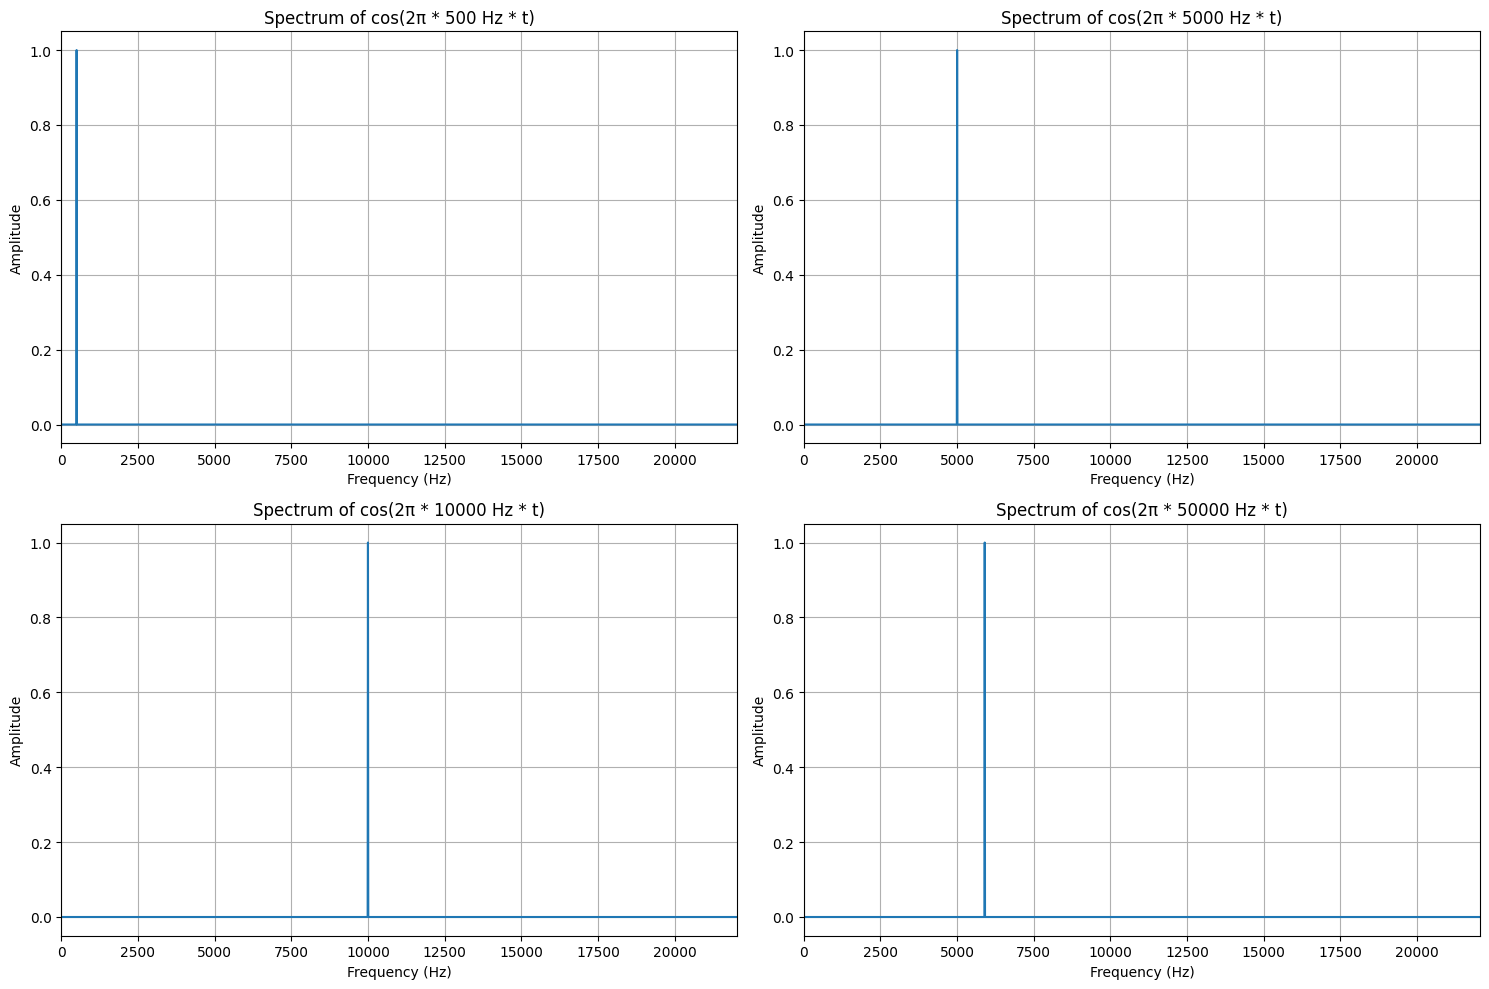

In [ ]:
# Sampling parameters
fs = 44100  # Sampling frequency in Hz
T_duration = 0.1 # Duration of the signal in seconds
t = np.linspace(0.0, T_duration, int(fs * T_duration), endpoint=False)

f_values = [500, 5000, 10000, 50000] # Frequencies to test in Hz

plt.figure(figsize=(15, 10))

for i, f in enumerate(f_values):
    # Generate the cosine signal
    x_t = np.cos(2 * np.pi * f * t)

    # Calculate the spectrum
    frequencies, amplitudes = calculate_spectrum(x_t, fs)

    # Plot the spectrum
    plt.subplot(2, 2, i + 1)
    plt.plot(frequencies, amplitudes)
    plt.title(f'Spectrum of cos(2π * {f} Hz * t)')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.xlim(0, fs / 2) # Limit x-axis to Nyquist frequency
    plt.tight_layout()

plt.show()


### (b) Comentário sobre os resultados obtidos

Vamos analisar os gráficos de espectro para as diferentes frequências:

*   **f = 500 Hz:** O espectro mostra um pico nítido e claro em 500 Hz. Isso é esperado, pois o sinal cosseno é um tom puro nesta frequência, e 500 Hz está bem abaixo da frequência de Nyquist (`fs/2 = 22050 Hz`). A FFT captura com precisão o componente de frequência fundamental.

*   **f = 5000 Hz:** Similarmente, para 5000 Hz, observamos um pico distinto em 5000 Hz. Esta frequência também está abaixo da frequência de Nyquist, então não ocorre aliasing, e o espectro é representado corretamente.

*   **f = 10000 Hz:** O espectro ainda mostra um pico claro em 10000 Hz. Esta frequência ainda está bem dentro do limite de Nyquist. A representação é precisa.

*   **f = 50000 Hz:** Este é o caso mais interessante. A frequência de amostragem `fs` é 44.1 kHz, o que significa que a frequência de Nyquist é `fs/2 = 22050 Hz`. Como a frequência do sinal `f = 50000 Hz` é *maior* que a frequência de Nyquist, **aliasing** ocorre. Em vez de ver um pico em 50000 Hz (o que é impossível de representar com esta taxa de amostragem), a FFT mostra um pico em uma frequência com aliasing. A frequência com aliasing pode ser calculada como `|f - k * fs|` onde `k` é um inteiro tal que o resultado esteja entre 0 e `fs/2`. Neste caso, `|50000 - 1 * 44100| = 5900 Hz`. Assim, o gráfico exibe um pico em 5900 Hz, que é o componente com aliasing do sinal de 50000 Hz. Isso demonstra a importância crítica do teorema de amostragem de Nyquist-Shannon.

# 2. Análise Espectral de Sinal Chirp (Varreduras Linear, Quadrática e Logarítmica)

### (a) Calculando o espectro de um chirp com varreduras de frequência linear, quadrática e logarítmica

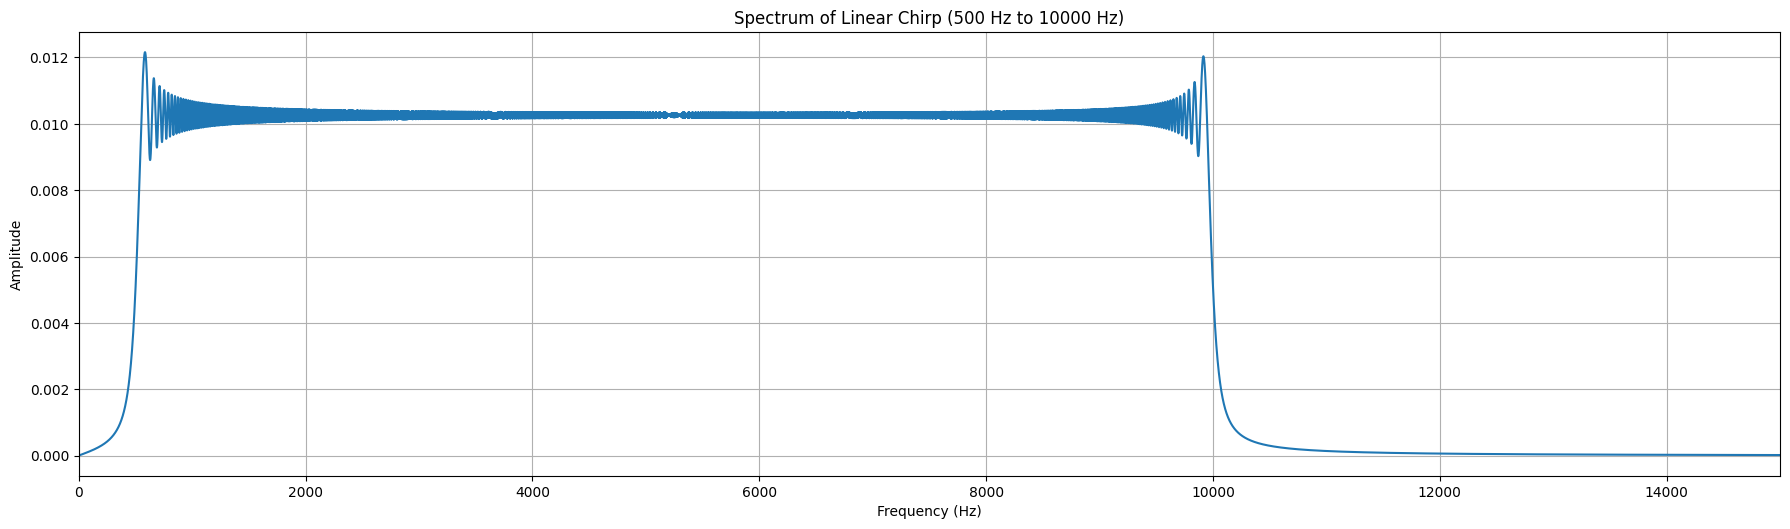

In [ ]:
# Chirp parameters
f0 = 500  # Initial frequency in Hz
f1 = 10000 # Final frequency in Hz
fs = 44100 # Sampling frequency in Hz
T_duration = 1 # Duration of the signal in seconds

# Time vector
t = np.linspace(0.0, T_duration, int(fs * T_duration), endpoint=False)

plt.figure(figsize=(18, 15))

### Linear Chirp
# Instantaneous frequency: f_inst(t) = f0 + (f1 - f0) * (t / T_duration)
# Phase: phi(t) = 2 * pi * integral(f_inst(tau) dtau)
k_linear = (f1 - f0) / T_duration
linear_chirp_signal = np.cos(2 * np.pi * (f0 * t + 0.5 * k_linear * t**2))

# Calculate spectrum
freq_linear, amp_linear = calculate_spectrum(linear_chirp_signal, fs)

# Plotting
plt.subplot(3, 1, 1)
plt.plot(freq_linear, amp_linear)
plt.title('Spectrum of Linear Chirp (500 Hz to 10000 Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, f1 * 1.5) # Show frequencies up to a bit beyond f1

plt.tight_layout()


#### Explicação do Chirp Linear

Um chirp linear é um sinal cuja frequência instantânea muda linearmente com o tempo. Se a frequência começa em $f_0$ e termina em $f_1$ durante uma duração $T$, a frequência instantânea $f_{inst}(t)$ pode ser descrita como:

$$f_{inst}(t) = f_0 + \frac{f_1 - f_0}{T} t$$

A fase do sinal é a integral de $2\pi f_{inst}(t)$ em relação ao tempo. O espectro de um chirp linear tipicamente mostra uma distribuição de frequências ao longo de sua faixa de varredura, pois a energia é distribuída ao longo do tempo.

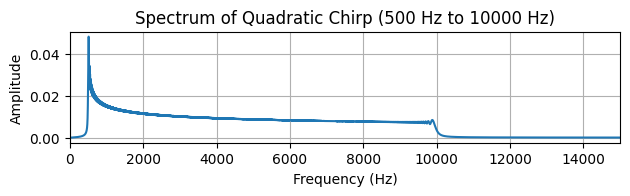

In [ ]:
### Quadratic Chirp
# Instantaneous frequency: f_inst(t) = f0 + (f1 - f0) * (t / T_duration)^2
# Phase: phi(t) = 2 * pi * integral(f_inst(tau) dtau)
k_quadratic = (f1 - f0) / (T_duration**2)
quadratic_chirp_signal = np.cos(2 * np.pi * (f0 * t + (k_quadratic / 3) * t**3))

# Calculate spectrum
freq_quadratic, amp_quadratic = calculate_spectrum(quadratic_chirp_signal, fs)

# Plotting
plt.subplot(3, 1, 2)
plt.plot(freq_quadratic, amp_quadratic)
plt.title('Spectrum of Quadratic Chirp (500 Hz to 10000 Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, f1 * 1.5)

plt.tight_layout()


#### Explicação do Chirp Quadrático

Um chirp quadrático é um sinal onde a frequência instantânea muda quadraticamente com o tempo. A fórmula para sua frequência instantânea é:

$$f_{inst}(t) = f_0 + \frac{f_1 - f_0}{T^2} t^2$$

Devido à mudança não linear na frequência, a distribuição de energia no espectro será diferente de um chirp linear, muitas vezes mostrando maior concentração de energia em direção ao final da varredura se $f_1 > f_0$.

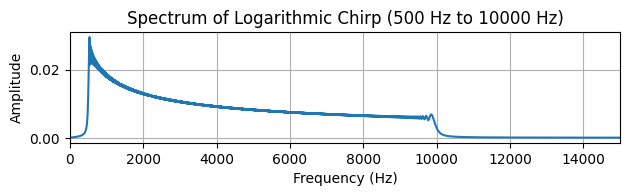

In [ ]:
### Logarithmic Chirp
# Instantaneous frequency: f_inst(t) = f0 * (f1/f0)^(t/T_duration)
# Phase: phi(t) = 2 * pi * integral(f_inst(tau) dtau)

# For logarithmic chirp, it's often easier to define the phase directly.
# The integral of an exponential function leads to an exponential term.
# The derivative of the phase should give 2*pi*f_inst(t)

log_chirp_signal = np.cos(2 * np.pi * f0 * T_duration / np.log(f1/f0) * ((f1/f0)**(t/T_duration) - 1))

# Calculate spectrum
freq_log, amp_log = calculate_spectrum(log_chirp_signal, fs)

# Plotting
plt.subplot(3, 1, 3)
plt.plot(freq_log, amp_log)
plt.title('Spectrum of Logarithmic Chirp (500 Hz to 10000 Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, f1 * 1.5)

plt.tight_layout()
plt.show()


#### Explicação do Chirp Logarítmico

Um chirp logarítmico (ou exponencial) é um sinal onde a frequência instantânea muda exponencialmente com o tempo. Sua frequência instantânea é dada por:

$$f_{inst}(t) = f_0 \left(\frac{f_1}{f_0}\right)^{\frac{t}{T}}$$

Este tipo de chirp é frequentemente usado em aplicações onde a percepção da frequência é logarítmica, como em áudio, ou para sistemas que respondem melhor a varreduras exponenciais. O espectro refletirá essa distribuição exponencial de energia ao longo da faixa de frequência.

### (b) Comentário sobre os resultados obtidos

Vamos analisar os gráficos de espectro para os diferentes tipos de chirp:

*   **Chirp Linear:** O espectro do chirp linear mostra uma distribuição de energia relativamente uniforme ao longo da faixa de frequência de 500 Hz a 10000 Hz. Não há picos nítidos e distintos como visto com tons puros. Isso ocorre porque o sinal varre continuamente essas frequências durante a duração do sinal, distribuindo sua energia por toda a faixa de varredura. A amplitude pode variar ligeiramente devido a efeitos de janelamento e à duração finita do sinal, mas a forma geral é uma banda larga cobrindo as frequências varridas.

*   **Chirp Quadrático:** Para o chirp quadrático, a varredura de frequência é não linear. Como a mudança de frequência é mais lenta no início (frequências mais baixas) e mais rápida em direção ao final (frequências mais altas) da varredura, podemos esperar uma distribuição de energia ligeiramente diferente. O espectro ainda será uma banda larga, mas a energia pode parecer mais concentrada ou espalhada de forma diferente ao longo da faixa de frequência em comparação com o chirp linear, refletindo a taxa não uniforme de mudança de frequência. Pode mostrar amplitudes mais altas em frequências onde o sinal passa mais tempo.

*   **Chirp Logarítmico:** A frequência do chirp logarítmico muda exponencialmente. Isso significa que o sinal passa mais tempo em frequências mais baixas e varre as frequências mais altas mais rapidamente. Consequentemente, o espectro do chirp logarítmico pode mostrar mais energia concentrada na extremidade inferior da faixa de frequência varrida (mais próximo de 500 Hz) e menos energia na extremidade superior (mais próximo de 10000 Hz) em comparação com um chirp linear ou quadrático. O espectro ainda será uma banda larga, mas sua forma será influenciada por essa taxa exponencial de mudança.

Em todos os casos, os espectros demonstram que os sinais de chirp, ao contrário dos tons puros, distribuem sua energia em uma faixa de frequências, e não em uma única frequência. A distribuição específica depende da natureza da varredura de frequência (linear, quadrática, logarítmica).

# 3. Análise do arquivo de áudio `handel.wav`

#### (a) Calculando o espectro do sinal de áudio

Sampling frequency of audio: 8192 Hz
Number of samples in audio: 73113


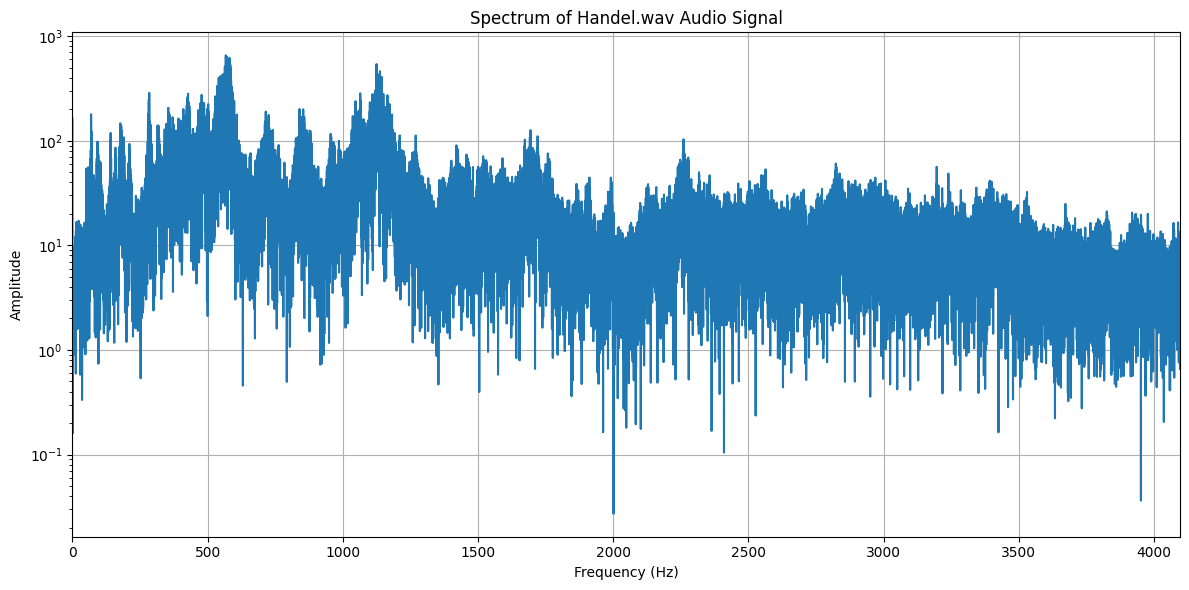

In [ ]:
from scipy.io import wavfile
from google.colab import files

# Check if the file already exists, if not, prompt user to upload
file_path = '/content/handel.wav'
try:
    with open(file_path, 'rb') as f:
        pass
except FileNotFoundError:
    print(f"O arquivo '{file_path}' não foi encontrado. Por favor, carregue o arquivo 'handel.wav'.")
    uploaded = files.upload()
    if 'handel.wav' not in uploaded:
        raise FileNotFoundError("O arquivo 'handel.wav' não foi carregado. Por favor, carregue o arquivo para continuar.")

# Load the audio file
fs_audio, audio_signal = wavfile.read(file_path)

print(f"Sampling frequency of audio: {fs_audio} Hz")
print(f"Number of samples in audio: {len(audio_signal)}")

# If the audio signal is stereo, take one channel
if len(audio_signal.shape) > 1:
    audio_signal = audio_signal[:, 0]

# Calculate the spectrum of the audio signal
freq_audio, amp_audio = calculate_spectrum(audio_signal, fs_audio)

# Plot the spectrum
plt.figure(figsize=(12, 6))
plt.plot(freq_audio, amp_audio)
plt.title('Spectrum of Handel.wav Audio Signal')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, fs_audio / 2) # Limit to Nyquist frequency
plt.yscale('log') # Log scale for better visualization of dynamic range
plt.tight_layout()
plt.show()

#### (b) Comentário sobre os resultados obtidos

O espectro do sinal de áudio `handel.wav`, como esperado para conteúdo musical, mostra uma rica distribuição de frequências em uma ampla faixa.

*   **Natureza de Banda Larga:** Ao contrário das ondas senoidais puras que mostravam picos nítidos e distintos, o sinal de áudio exibe um espectro de banda larga com muitos componentes de frequência presentes simultaneamente. Esta é uma característica de sons complexos como música, que são compostos por muitas frequências diferentes (fundamentais e harmônicas) que mudam ao longo do tempo.

*   **Distribuição de Energia:** Podemos observar que a energia tende a ser maior em frequências mais baixas e diminui gradualmente à medida que a frequência aumenta. Esta é uma característica comum de muitos sons naturais e peças musicais, onde o conteúdo melódico e harmônico fundamental reside frequentemente nas faixas de baixa e média frequência, enquanto as frequências mais altas contribuem para o timbre e detalhes dos sobretons.

*   **Presença de Picos:** Embora de banda larga, pode haver picos notáveis em certas frequências. Esses picos correspondem às notas musicais dominantes ou séries harmônicas presentes no trecho de áudio. Por exemplo, se um instrumento específico ou nota vocal for proeminente, sua frequência fundamental e vários de seus harmônicos podem aparecer como picos discerníveis no espectro.

*   **Faixa Dinâmica (Escala Logarítmica):** Ao plotar a amplitude em uma escala logarítmica (`plt.yscale('log')`), podemos visualizar melhor a ampla faixa dinâmica de frequências presentes. Isso nos permite ver componentes de frequência fortes e fracos que, de outra forma, poderiam ser obscurecidos em uma escala de amplitude linear.

Em resumo, o espectro fornece uma impressão digital no domínio da frequência do conteúdo de áudio, revelando a complexa interação de frequências que constituem a peça musical.

# 4. Subamostragem de um sinal `x[n]` por um fator de M

#### (a) Criando uma função para realizar a subamostragem

In [ ]:
import numpy as np

def downsample_signal(signal, M):
    """
    Downsamples a discrete signal by a factor M.
    y[n] = x[nM]

    Args:
        signal (np.array): The input discrete signal.
        M (int): The downsampling factor.

    Returns:
        np.array: The downsampled signal.
    """
    if not isinstance(M, int) or M <= 0:
        raise ValueError("Downsampling factor M must be a positive integer.")

    # Select every M-th sample
    downsampled_signal = signal[::M]
    return downsampled_signal

print("Downsampling function `downsample_signal` created.")

Downsampling function `downsample_signal` created.


#### (b) Subamostrando o sinal de áudio por fatores de M ∈ {2, 4, 8}

In [ ]:
# Original audio signal and sampling frequency are already loaded from previous steps
# audio_signal, fs_audio

M_values = [2, 4, 8]
downsampled_signals = {}
downsampled_fs = {}

for M in M_values:
    downsampled_signals[M] = downsample_signal(audio_signal, M)
    downsampled_fs[M] = fs_audio // M
    print(f"Signal downsampled by M={M}: New length = {len(downsampled_signals[M])}, New fs = {downsampled_fs[M]} Hz")

# Also store the original signal for comparison
downsampled_signals[1] = audio_signal
downsampled_fs[1] = fs_audio

Signal downsampled by M=2: New length = 36557, New fs = 4096 Hz
Signal downsampled by M=4: New length = 18279, New fs = 2048 Hz
Signal downsampled by M=8: New length = 9140, New fs = 1024 Hz


#### (c) Calculando o espectro dos sinais subamostrados

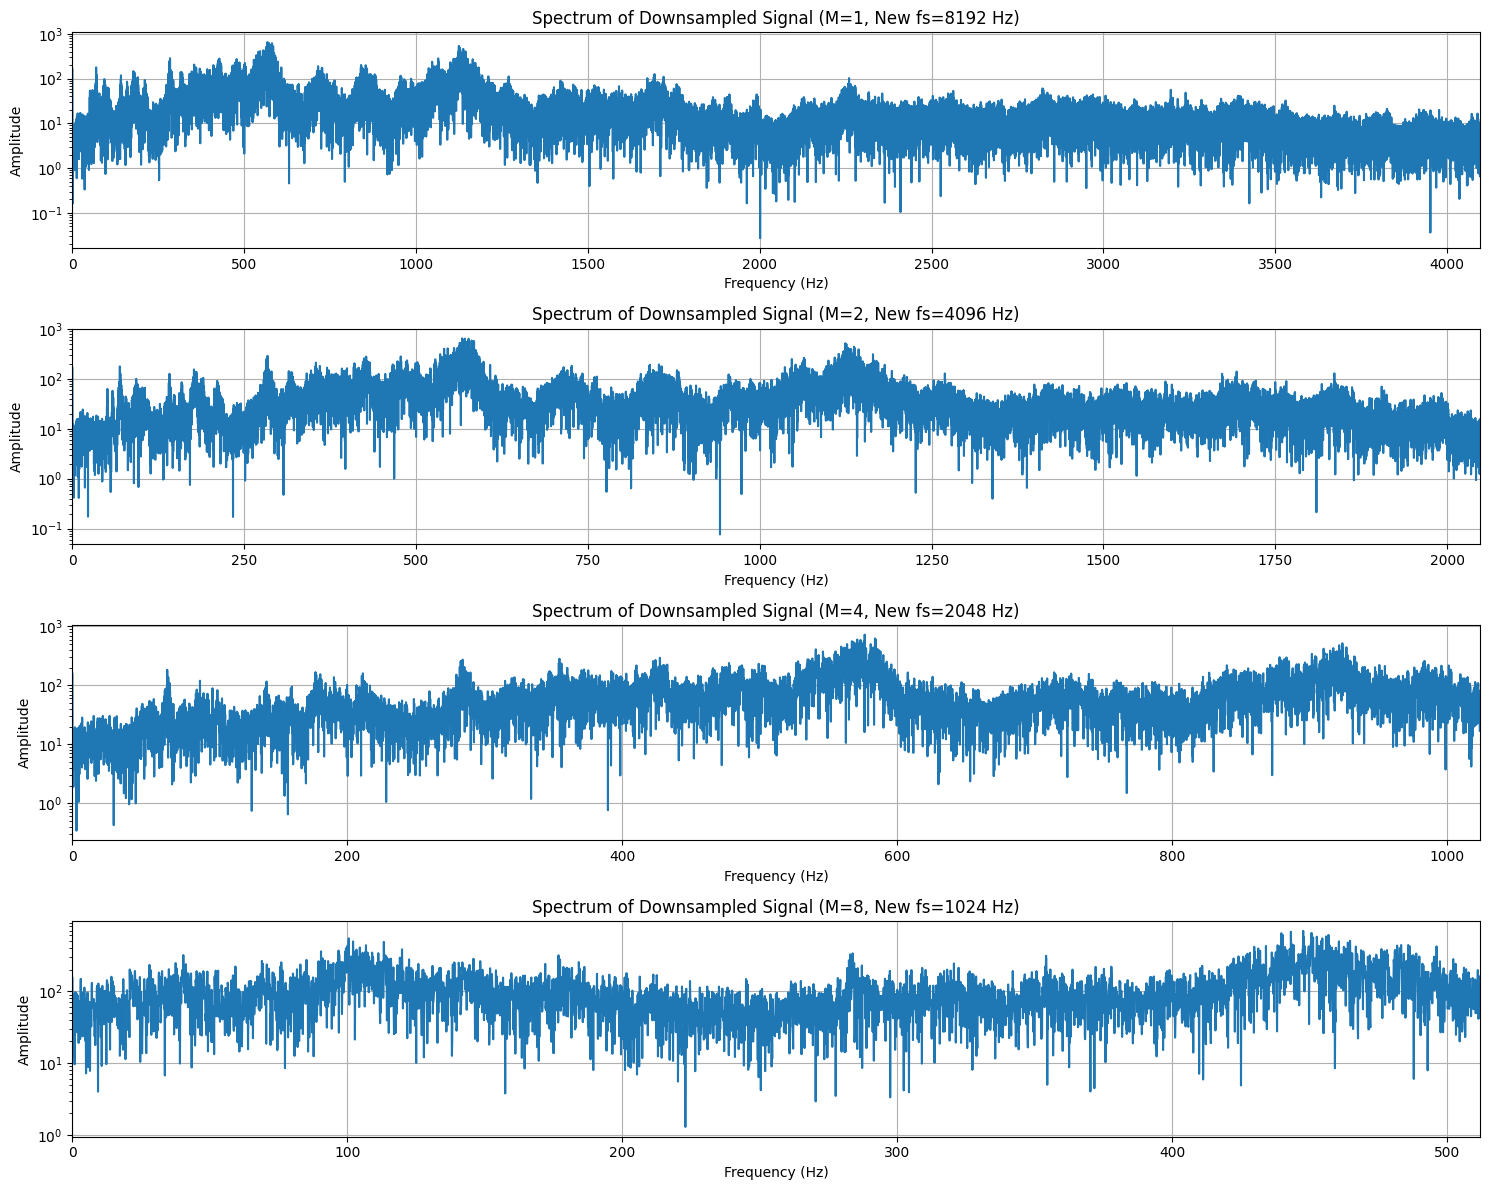

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 12))

# Include the original signal's spectrum for comparison
M_display_values = [1, 2, 4, 8]

for i, M in enumerate(M_display_values):
    current_signal = downsampled_signals[M]
    current_fs = downsampled_fs[M]

    # Calculate spectrum
    freq, amp = calculate_spectrum(current_signal, current_fs)

    # Plotting
    plt.subplot(len(M_display_values), 1, i + 1)
    plt.plot(freq, amp)
    plt.title(f'Spectrum of Downsampled Signal (M={M}, New fs={current_fs} Hz)')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.xlim(0, current_fs / 2) # Limit to Nyquist frequency of the downsampled signal
    plt.yscale('log') # Log scale for better visualization

plt.tight_layout()
plt.show()

#### (d) Ouvindo os sinais subamostrados

In [ ]:
from IPython.display import Audio

# Original Signal
print("Original Signal (M=1):")
display(Audio(data=downsampled_signals[1], rate=downsampled_fs[1]))

# Downsampled by M=2
print("Downsampled Signal (M=2):")
display(Audio(data=downsampled_signals[2], rate=downsampled_fs[2]))

# Downsampled by M=4
print("Downsampled Signal (M=4):")
display(Audio(data=downsampled_signals[4], rate=downsampled_fs[4]))

# Downsampled by M=8
print("Downsampled Signal (M=8):")
display(Audio(data=downsampled_signals[8], rate=downsampled_fs[8]))

Original Signal (M=1):


Downsampled Signal (M=2):


Downsampled Signal (M=4):


Downsampled Signal (M=8):


#### (e) Comentário sobre os resultados obtidos

Vamos analisar os efeitos da subamostragem tanto no espectro quanto na qualidade de áudio percebida:

**Análise Espectral:**

*   **M=1 (Sinal Original):** O espectro mostra o conteúdo de frequência completo do sinal original `handel.wav`, estendendo-se até sua frequência de Nyquist (`fs_audio / 2 = 8192 / 2 = 4096 Hz`).

*   **M=2 (Subamostrado, Nova fs = 4096 Hz):** Quando subamostrado por um fator de 2, a nova frequência de amostragem torna-se `fs_audio / 2 = 4096 Hz`. Consequentemente, a nova frequência de Nyquist é `4096 / 2 = 2048 Hz`. O gráfico de espectro mostrará conteúdo de frequência apenas até esta nova frequência de Nyquist. Quaisquer frequências no sinal original acima de 2048 Hz são efetivamente removidas ou *aliased* para a faixa audível, embora a subamostragem simples sem filtragem anti-aliasing principalmente descarte essas frequências mais altas.

*   **M=4 (Subamostrado, Nova fs = 2048 Hz):** A nova frequência de amostragem é `fs_audio / 4 = 2048 Hz`, e a frequência de Nyquist é `2048 / 2 = 1024 Hz`. O espectro é ainda mais comprimido, mostrando apenas frequências até 1024 Hz. Um conteúdo significativo de alta frequência do sinal original é perdido.

*   **M=8 (Subamostrado, Nova fs = 1024 Hz):** Com uma nova frequência de amostragem de `fs_audio / 8 = 1024 Hz`, a frequência de Nyquist cai para `1024 / 2 = 512 Hz`. Neste ponto, a maior parte dos detalhes musicais e brilho terão desaparecido, e o espectro refletirá apenas os componentes de frequência muito baixos.

**Análise Auditiva:**

*   **M=1 (Sinal Original):** O áudio deve soar normal, como gravado.

*   **M=2 (Subamostrado):** O áudio começará a soar um pouco monótono ou abafado, pois algumas das frequências mais altas foram removidas. A degradação percebida da qualidade será perceptível, mas ainda pode ser razoavelmente aceitável.

*   **M=4 (Subamostrado):** A qualidade do áudio vai se degradar significativamente. Grande parte da clareza e brilho se perderá, e o som parecerá muito 'flat'. Vai soar como ouvir por um alto-falante de qualidade muito baixa ou por um telefone.

*   **M=8 (Subamostrado):** Nesse nível de subamostragem, o áudio será mal reconhecível como música. Vai soar extremamente distorcido, de fidelidade muito baixa, e a maior parte das informações originais será perdida, mantendo apenas o conteúdo rítmico mais básico e de frequência muito baixa.

**Conclusão:**

A simples redução de amostragem selecionando cada M-ésima amostra reduz efetivamente a taxa de amostragem e, portanto, a frequência de Nyquist. Isso resulta na perda de todo o conteúdo de frequência acima da nova frequência de Nyquist. No áudio, isso se manifesta como uma perda progressiva de clareza, brilho e fidelidade geral, fazendo com que o sinal soe abafado e, eventualmente, ininteligível à medida que M aumenta. Para evitar essa degradação severa, a filtragem adequada de anti-aliasing antes da reamostragem é crucial em aplicações práticas.

# 5. Repetindo a subamostragem usando `scipy.signal.resample()` e comparando resultados

#### (a) Criando uma função para reamostragem usando `scipy.signal.resample()`

In [ ]:
from scipy.signal import resample

def resample_signal_scipy(signal, original_fs, target_fs):
    """
    Resamples a signal to a new sampling frequency using scipy.signal.resample.

    Args:
        signal (np.array): The input time-domain signal.
        original_fs (float): The original sampling frequency.
        target_fs (float): The target sampling frequency.

    Returns:
        np.array: The resampled signal.
    """
    num_samples_target = int(len(signal) * (target_fs / original_fs))
    resampled_signal = resample(signal, num_samples_target)
    return resampled_signal

print("Resampling function `resample_signal_scipy` created.")

Resampling function `resample_signal_scipy` created.


#### (b) Reamostrando o sinal de áudio por fatores de M ∈ {2, 4, 8} usando `resample_signal_scipy`

In [ ]:
M_values = [2, 4, 8]
resampled_signals_scipy = {}
resampled_fs_scipy = {}

# Original signal and fs are already loaded
# audio_signal, fs_audio

for M in M_values:
    target_fs = fs_audio // M
    resampled_signals_scipy[M] = resample_signal_scipy(audio_signal, fs_audio, target_fs)
    resampled_fs_scipy[M] = target_fs
    print(f"Signal resampled by M={M} (target fs={target_fs}): New length = {len(resampled_signals_scipy[M])}, New fs = {resampled_fs_scipy[M]} Hz")

# Also store the original signal for comparison
resampled_signals_scipy[1] = audio_signal
resampled_fs_scipy[1] = fs_audio

Signal resampled by M=2 (target fs=4096): New length = 36556, New fs = 4096 Hz
Signal resampled by M=4 (target fs=2048): New length = 18278, New fs = 2048 Hz
Signal resampled by M=8 (target fs=1024): New length = 9139, New fs = 1024 Hz


#### (c) Calculando o espectro dos sinais reamostrados

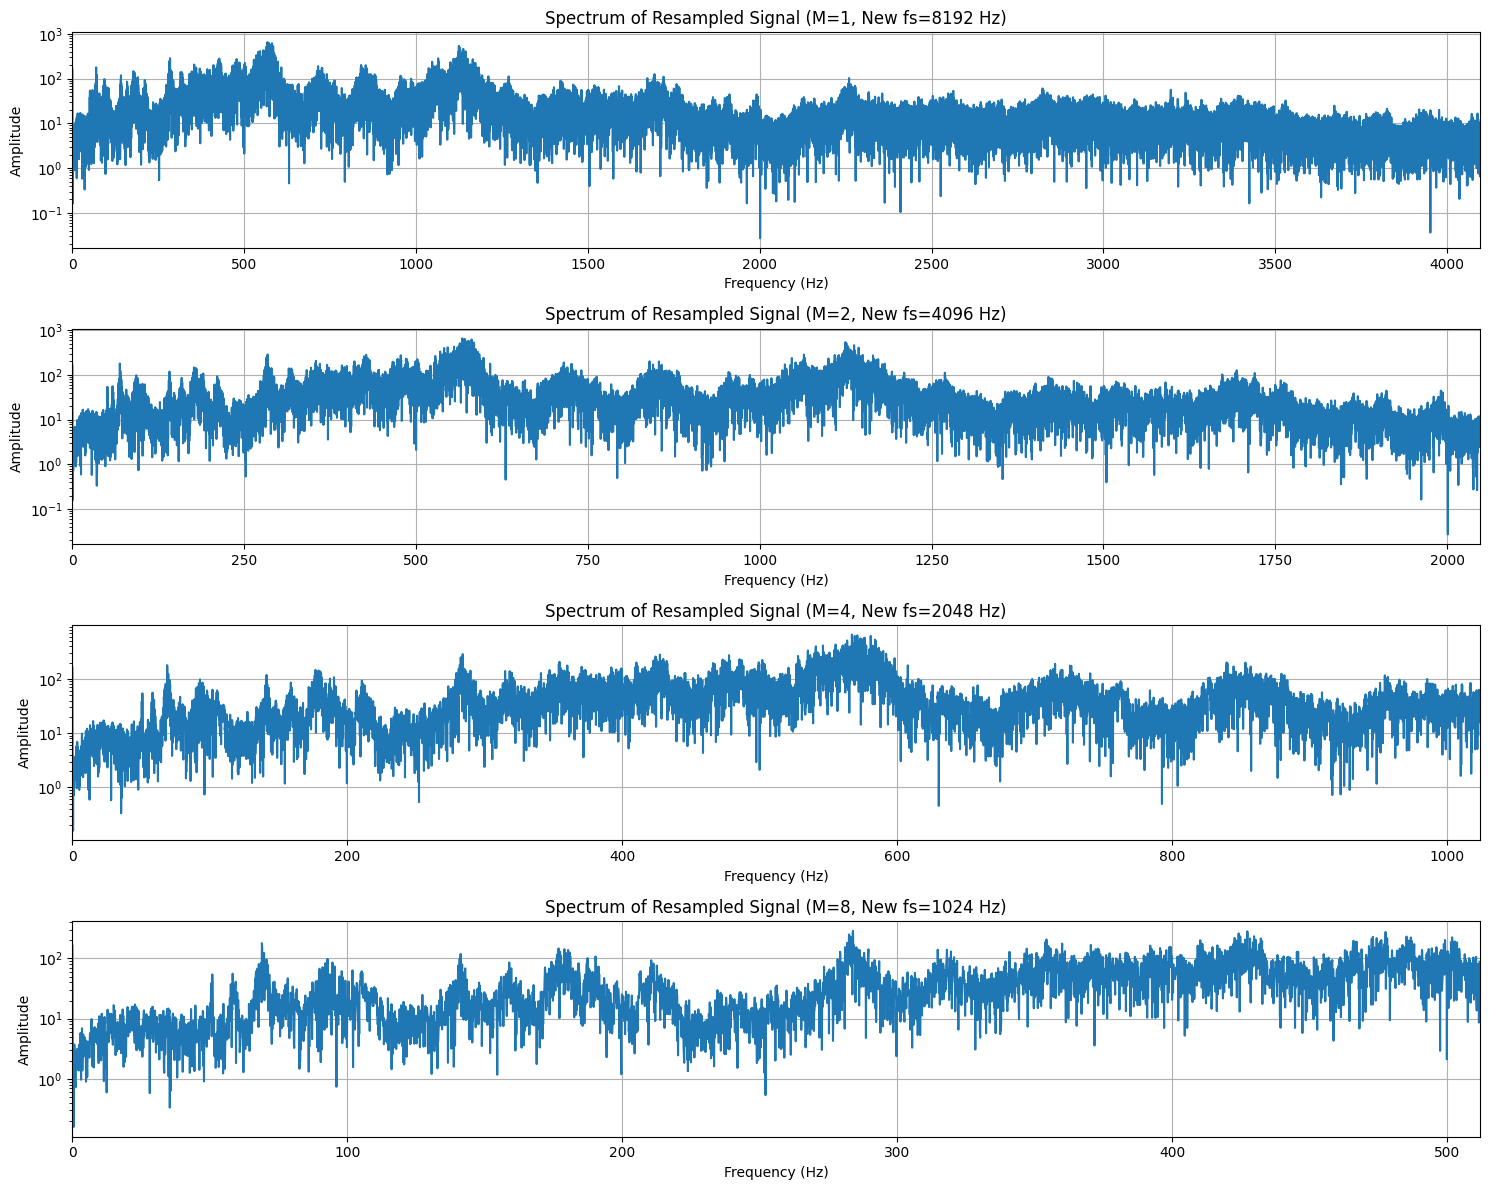

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 12))

# Include the original signal's spectrum for comparison
M_display_values = [1, 2, 4, 8]

for i, M in enumerate(M_display_values):
    current_signal = resampled_signals_scipy[M]
    current_fs = resampled_fs_scipy[M]

    # Calculate spectrum
    freq, amp = calculate_spectrum(current_signal, current_fs)

    # Plotting
    plt.subplot(len(M_display_values), 1, i + 1)
    plt.plot(freq, amp)
    plt.title(f'Spectrum of Resampled Signal (M={M}, New fs={current_fs} Hz)')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.xlim(0, current_fs / 2) # Limit to Nyquist frequency of the resampled signal
    plt.yscale('log') # Log scale for better visualization

plt.tight_layout()
plt.show()

#### (d) Ouvindo os sinais reamostrados

In [ ]:
from IPython.display import Audio

# Original Signal
print("Original Signal (M=1):")
display(Audio(data=resampled_signals_scipy[1], rate=resampled_fs_scipy[1]))

# Resampled by M=2
print("Resampled Signal (M=2):")
display(Audio(data=resampled_signals_scipy[2], rate=resampled_fs_scipy[2]))

# Resampled by M=4
print("Resampled Signal (M=4):")
display(Audio(data=resampled_signals_scipy[4], rate=resampled_fs_scipy[4]))

# Resampled by M=8
print("Resampled Signal (M=8):")
display(Audio(data=resampled_signals_scipy[8], rate=resampled_fs_scipy[8]))

Original Signal (M=1):


Resampled Signal (M=2):


Resampled Signal (M=4):


Resampled Signal (M=8):


#### (e) Comparando os resultados obtidos usando `scipy.signal.resample()` versus subamostragem personalizada

**1. Diferenças Espectrais:**

*   **Subamostragem Personalizada (Decimação Simples):** A função personalizada `downsample_signal` simplesmente selecionou cada M-ésima amostra. Este método, conhecido como *decimação sem filtragem anti-aliasing*, reduz efetivamente a taxa de amostragem e, portanto, a frequência de Nyquist. Quaisquer componentes de frequência no sinal original que estivessem acima da *nova* frequência de Nyquist teriam sofrido aliasing (dobrados) para a faixa de frequência audível. Embora nosso `xlim` para plotagem corte frequências acima da nova Nyquist, o aliasing subjacente ainda poderia estar presente, embora menos visível se os componentes aliased fossem muito fracos.

*   **`scipy.signal.resample()`:** Esta função realiza a reamostragem usando a Transformada Rápida de Fourier (FFT). Criticamente, ela inclui implicitamente um filtro anti-aliasing. Antes da subamostragem no domínio do tempo, `scipy.signal.resample()` filtra efetivamente quaisquer componentes de frequência no sinal original que causariam aliasing na nova e mais baixa taxa de amostragem. Isso significa que os espectros dos sinais reamostrados com `scipy.signal.resample()` devem mostrar um corte mais limpo na nova frequência de Nyquist, com aliasing significativamente reduzido ou inexistente acima deste novo limite. A energia acima da nova frequência de Nyquist é verdadeiramente removida, e não apenas dobrada.

**2. Diferenças Auditivas:**

*   **Subamostragem Personalizada:** Como discutido anteriormente, a decimação simples leva a uma rápida degradação da qualidade do áudio. Frequências mais altas são perdidas, e informações cruciais são simplesmente descartadas. Se o aliasing fosse significativo, introduziria distorções e artefatos audíveis (por exemplo, sons metálicos, 'muddiness').

*   **`scipy.signal.resample()`:** Devido ao filtro anti-aliasing embutido, a qualidade de áudio dos sinais reamostrados com `scipy.signal.resample()` deve ser superior aos sinais simplesmente subamostrados, especialmente para valores maiores de M. Embora as frequências mais altas ainda sejam removidas (conforme ditado pela nova frequência de Nyquist), esta remoção é feita de forma suave e correta. O áudio reamostrado ainda soará monótono ou abafado porque o conteúdo de alta frequência realmente desapareceu, mas deve estar livre dos sons ásperos, distorcidos ou metálicos que o aliasing introduziria na subamostragem personalizada.

**Conclusão:**

`scipy.signal.resample()` é uma forma muito mais robusta e adequada de alterar a taxa de amostragem de um sinal, especialmente ao reduzi-la. Ele lida com a etapa crítica do filtro anti-aliasing, que previne artefatos espectrais indesejados e preserva a integridade do conteúdo de frequência restante. A decimação simples, embora ilustrativa do princípio, raramente é usada na prática para amostragem de áudio sem um filtro anti-aliasing anterior, devido à severa degradação de qualidade causada pelo aliasing. Os gráficos espectrais devem confirmar visualmente o corte mais limpo nas saídas, e a experiência auditiva deve destacar a qualidade melhorada do `scipy.signal.resample()`.

# 6. Sobreamostragem do sinal handel.wav por inserção de zeros

#### (a) Criando uma função para realizar a sobreamostragem

In [ ]:
import numpy as np

def oversample_signal(signal, M):
    """
    Oversamples a discrete signal by inserting M-1 zeros between each sample.
    Note: This is a basic zero-insertion oversampling. A proper oversampling
    implementation usually involves an anti-imaging low-pass filter after zero-insertion.

    Args:
        signal (np.array): The input discrete signal.
        M (int): The oversampling factor.

    Returns:
        np.array: The oversampled signal with zeros inserted.
    """
    if not isinstance(M, int) or M <= 0:
        raise ValueError("Oversampling factor M must be a positive integer.")

    # Create an array of zeros with the new length
    # New length = original_length * M
    oversampled_length = len(signal) * M
    oversampled_signal = np.zeros(oversampled_length, dtype=signal.dtype)

    # Place the original samples at every M-th position
    oversampled_signal[::M] = signal
    return oversampled_signal

print("Oversampling function `oversample_signal` created.")

Oversampling function `oversample_signal` created.


#### (b) Sobreamostrando o sinal de áudio por fatores de M ∈ {2, 4, 8}

In [ ]:
# Original audio signal and sampling frequency are already loaded
# audio_signal, fs_audio

M_values = [2, 4, 8]
oversampled_signals = {}
oversampled_fs = {}

# The original signal should also be considered as M=1 oversampling (no change)
oversampled_signals[1] = audio_signal
oversampled_fs[1] = fs_audio

for M in M_values:
    # Oversample the *original* audio signal
    oversampled_signals[M] = oversample_signal(audio_signal, M)
    # The new sampling frequency is M * original_fs
    oversampled_fs[M] = fs_audio * M
    print(f"Signal oversampled by M={M}: New length = {len(oversampled_signals[M])}, New fs = {oversampled_fs[M]} Hz")

Signal oversampled by M=2: New length = 146226, New fs = 16384 Hz
Signal oversampled by M=4: New length = 292452, New fs = 32768 Hz
Signal oversampled by M=8: New length = 584904, New fs = 65536 Hz


#### (c) Calculando o espectro dos sinais sobreamostrados

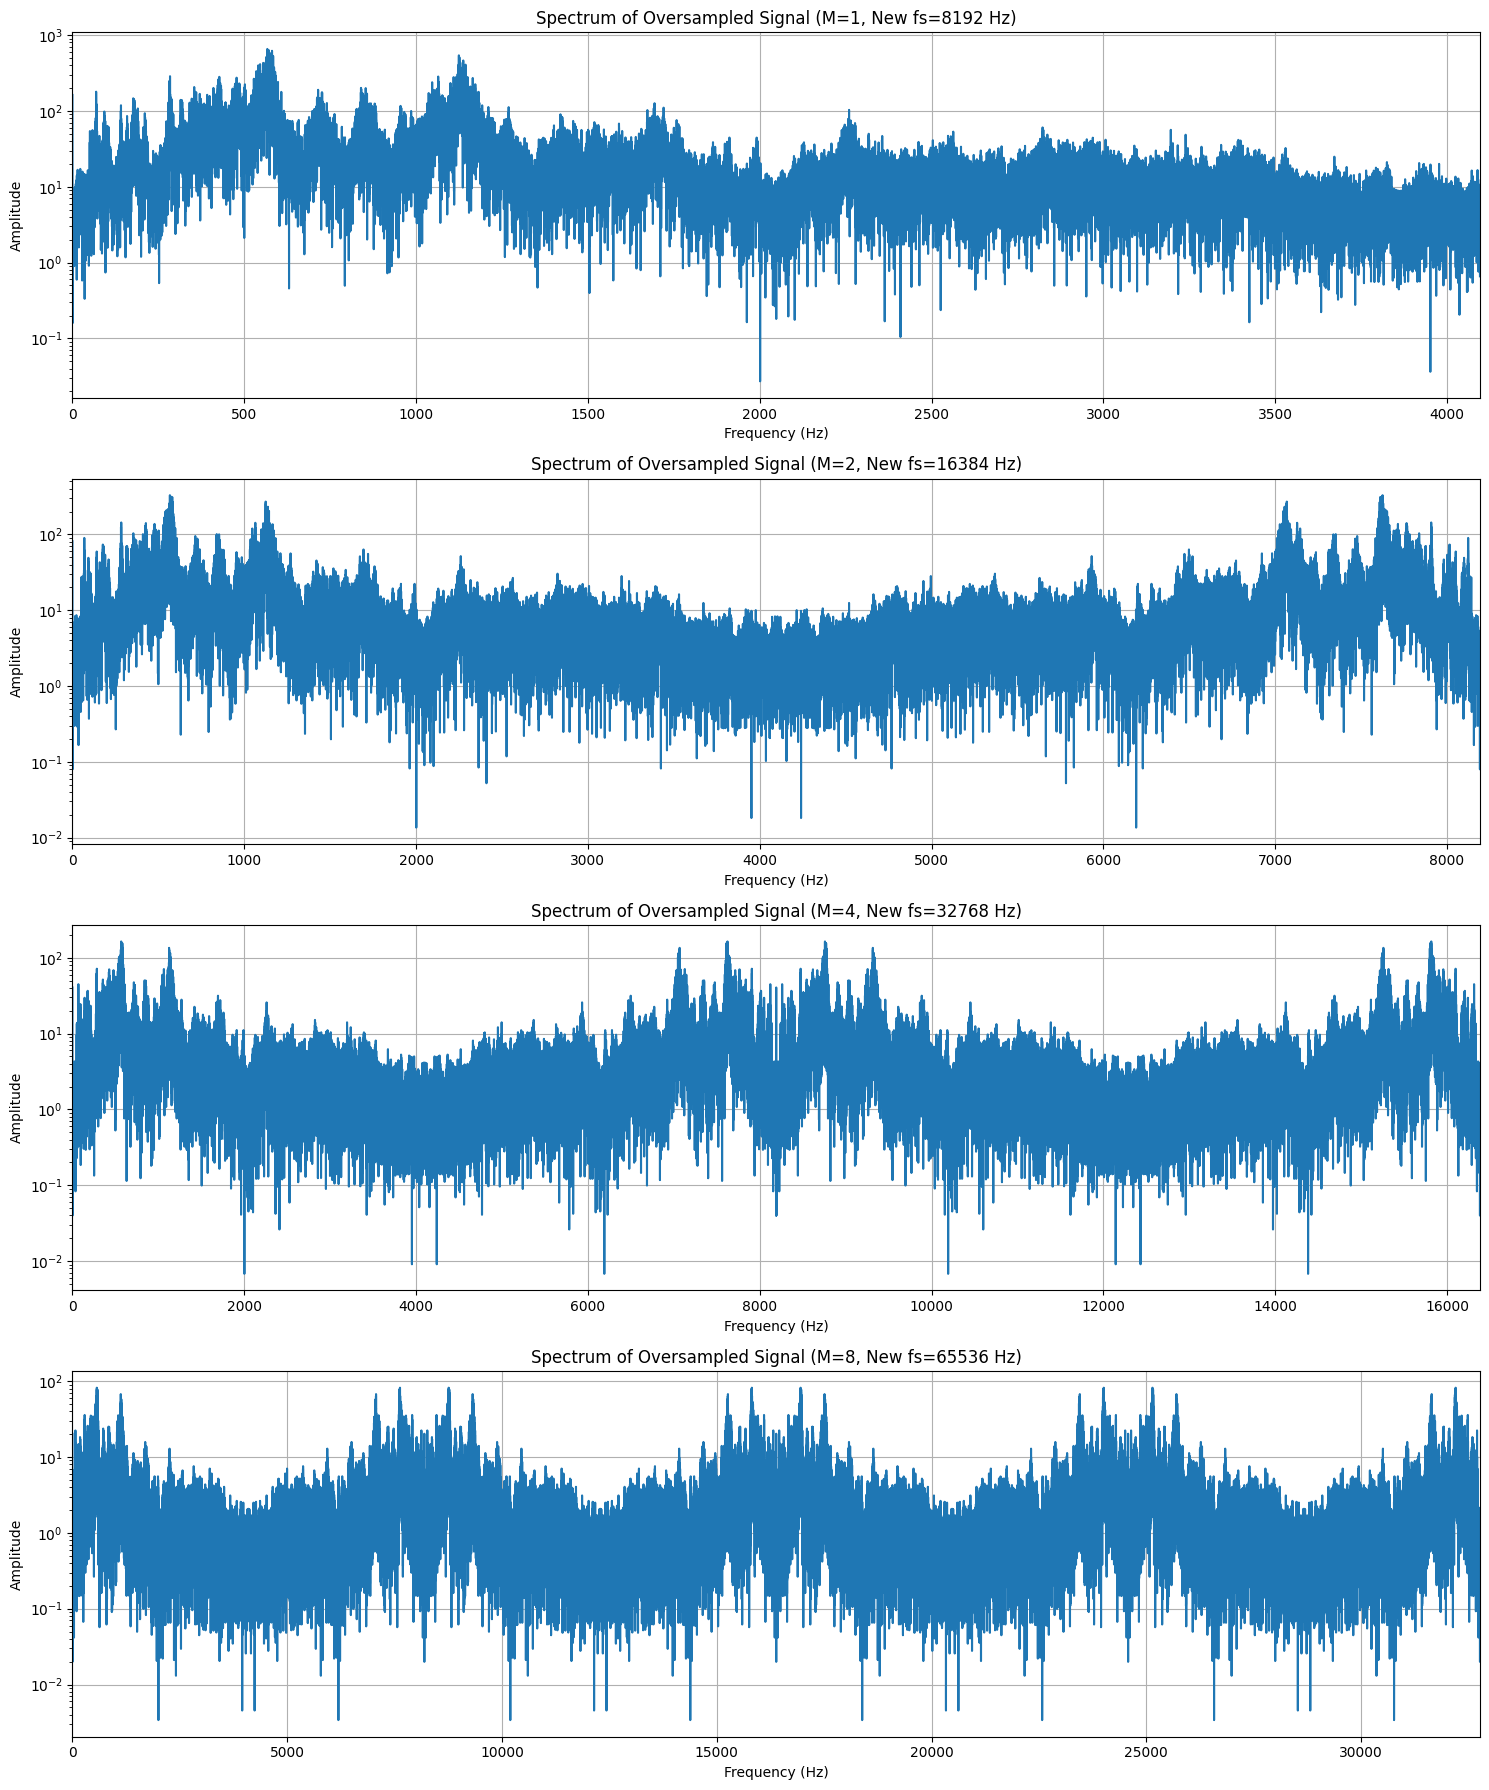

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 18))

# Include the original signal's spectrum for comparison
M_display_values = [1, 2, 4, 8]

for i, M in enumerate(M_display_values):
    current_signal = oversampled_signals[M]
    current_fs = oversampled_fs[M]

    # Calculate spectrum
    freq, amp = calculate_spectrum(current_signal, current_fs)

    # Plotting
    plt.subplot(len(M_display_values), 1, i + 1)
    plt.plot(freq, amp)
    plt.title(f'Spectrum of Oversampled Signal (M={M}, New fs={current_fs} Hz)')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    # Limit to Nyquist frequency of the original signal (or new Nyquist if M=1)
    # For oversampling, the original signal's bandwidth remains the same
    plt.xlim(0, fs_audio / 2 * M)
    plt.yscale('log') # Log scale for better visualization

plt.tight_layout()
plt.show()

#### (d) Ouvindo os sinais sobreamostrados

In [ ]:
from IPython.display import Audio

# Original Signal
print("Original Signal (M=1):")
display(Audio(data=oversampled_signals[1], rate=oversampled_fs[1]))

# Oversampled by M=2
print("Oversampled Signal (M=2):")
display(Audio(data=oversampled_signals[2], rate=oversampled_fs[2]))

# Oversampled by M=4
print("Oversampled Signal (M=4):")
display(Audio(data=oversampled_signals[4], rate=oversampled_fs[4]))

# Oversampled by M=8
print("Oversampled Signal (M=8):")
display(Audio(data=oversampled_signals[8], rate=oversampled_fs[8]))

Original Signal (M=1):


Oversampled Signal (M=2):


Oversampled Signal (M=4):


Oversampled Signal (M=8):


#### (e) Comentário sobre os resultados obtidos

Vamos analisar os efeitos da sobreamostragem por simples inserção de zeros tanto no espectro quanto na qualidade de áudio percebida:

**Análise Espectral:**

*   **M=1 (Sinal Original):** O espectro mostra o conteúdo de frequência completo do sinal original `handel.wav`, estendendo-se até sua frequência de Nyquist (`fs_audio / 2 = 8192 / 2 = 4096 Hz`).

*   **Sobreamostragem por M (por exemplo, M=2, 4, 8):** Quando inserimos M-1 zeros entre cada amostra, a taxa de amostragem aumenta efetivamente por um fator de M (por exemplo, `fs_audio * M`). Isso significa que a nova frequência de Nyquist também é M vezes maior (`fs_audio * M / 2`). No entanto, a simples inserção de zeros não cria nova informação de frequência dentro da largura de banda original do sinal. Em vez disso, ela cria *imagens espectrais* (ou réplicas) do espectro original do sinal, centradas em múltiplos da frequência de amostragem original (`fs_audio`, `2*fs_audio`, etc.)
    *   Para **M=2**, o espectro mostrará o conteúdo do sinal original até 4096 Hz, mas também uma réplica deste espectro centrada em 8192 Hz (a `fs_audio` original). A nova Nyquist é `8192 * 2 / 2 = 8192 Hz`.
    *   Para **M=4**, réplicas aparecerão em torno de `fs_audio`, `2*fs_audio`, `3*fs_audio`, etc., até a nova frequência de Nyquist (`8192 * 4 / 2 = 16384 Hz`).
    *   Para **M=8**, ainda mais réplicas serão visíveis na faixa de frequência mais ampla, até `8192 * 8 / 2 = 32768 Hz`.

    Essas imagens são uma consequência direta de não aplicar um filtro passa-baixas anti-imagem após a inserção de zeros. Um processo de sobreamostragem (interpolação) adequado envolveria passar este sinal com zeros inseridos através de um filtro passa-baixas com um corte na frequência de Nyquist original (`fs_audio / 2`) para remover essas imagens espectrais, deixando apenas o espectro do sinal original esticado na faixa de frequência mais ampla.

**Análise Auditiva:**

*   **M=1 (Sinal Original):** O áudio deve soar normal.

*   **Sobreamostragem por M (por exemplo, M=2, 4, 8):** Ao ouvir os sinais sobreamostrados com inserção de zeros, eles provavelmente soarão distorcidos, "clicados" ou "granulados". Isso ocorre porque os valores zero abruptos introduzidos criam componentes de alta frequência que não estavam presentes no sinal original, que são as imagens espectrais vistas na FFT. O ouvido humano percebe esses componentes espúrios de alta frequência como ruído ou distorção. À medida que M aumenta, o número de zeros entre as amostras aumenta, tornando o sinal ainda mais esparso e a distorção audível mais pronunciada. Sem um filtro passa-baixas, esses sinais não são versões interpoladas suavemente do original.

**Comparação com `scipy.signal.resample()` (do contexto da questão anterior):**

*   Em contraste com este método básico de inserção de zeros, `scipy.signal.resample()` (e outras técnicas avançadas de reamostragem) realiza a filtragem anti-imagem (interpolação) adequada após aumentar implicitamente a taxa de amostragem. Essa filtragem remove as imagens espectrais, resultando em um sinal sobreamostrado de qualidade muito mais suave e superior que preserva a largura de banda original do sinal sem introduzir conteúdo de alta frequência espúrio ou distorção audível.

# 7. Sobreamostragem usando `scipy.signal.resample()` e comparando resultados

#### (a) Aplicando `scipy.signal.resample()` para sobreamostragem por M ∈ {2, 4, 8}

In [ ]:
from scipy.signal import resample

M_values_upsample = [2, 4, 8]
oversampled_scipy = {}
oversampled_fs_scipy = {}

# O sinal original e fs já estão carregados
# audio_signal, fs_audio

# Incluir o sinal original para comparação
oversampled_scipy[1] = audio_signal
oversampled_fs_scipy[1] = fs_audio

for M in M_values_upsample:
    target_fs_upsample = fs_audio * M
    # scipy.signal.resample pode ser usado para upsampling também
    oversampled_scipy[M] = resample(audio_signal, int(len(audio_signal) * M))
    oversampled_fs_scipy[M] = target_fs_upsample
    print(f"Sinal sobreamostrado por M={M} (target fs={target_fs_upsample}): Novo comprimento = {len(oversampled_scipy[M])}, Novo fs = {oversampled_fs_scipy[M]} Hz")


Sinal sobreamostrado por M=2 (target fs=16384): Novo comprimento = 146226, Novo fs = 16384 Hz
Sinal sobreamostrado por M=4 (target fs=32768): Novo comprimento = 292452, Novo fs = 32768 Hz
Sinal sobreamostrado por M=8 (target fs=65536): Novo comprimento = 584904, Novo fs = 65536 Hz


#### (b) Calculando o espectro dos sinais sobreamostrados com `scipy.signal.resample()`

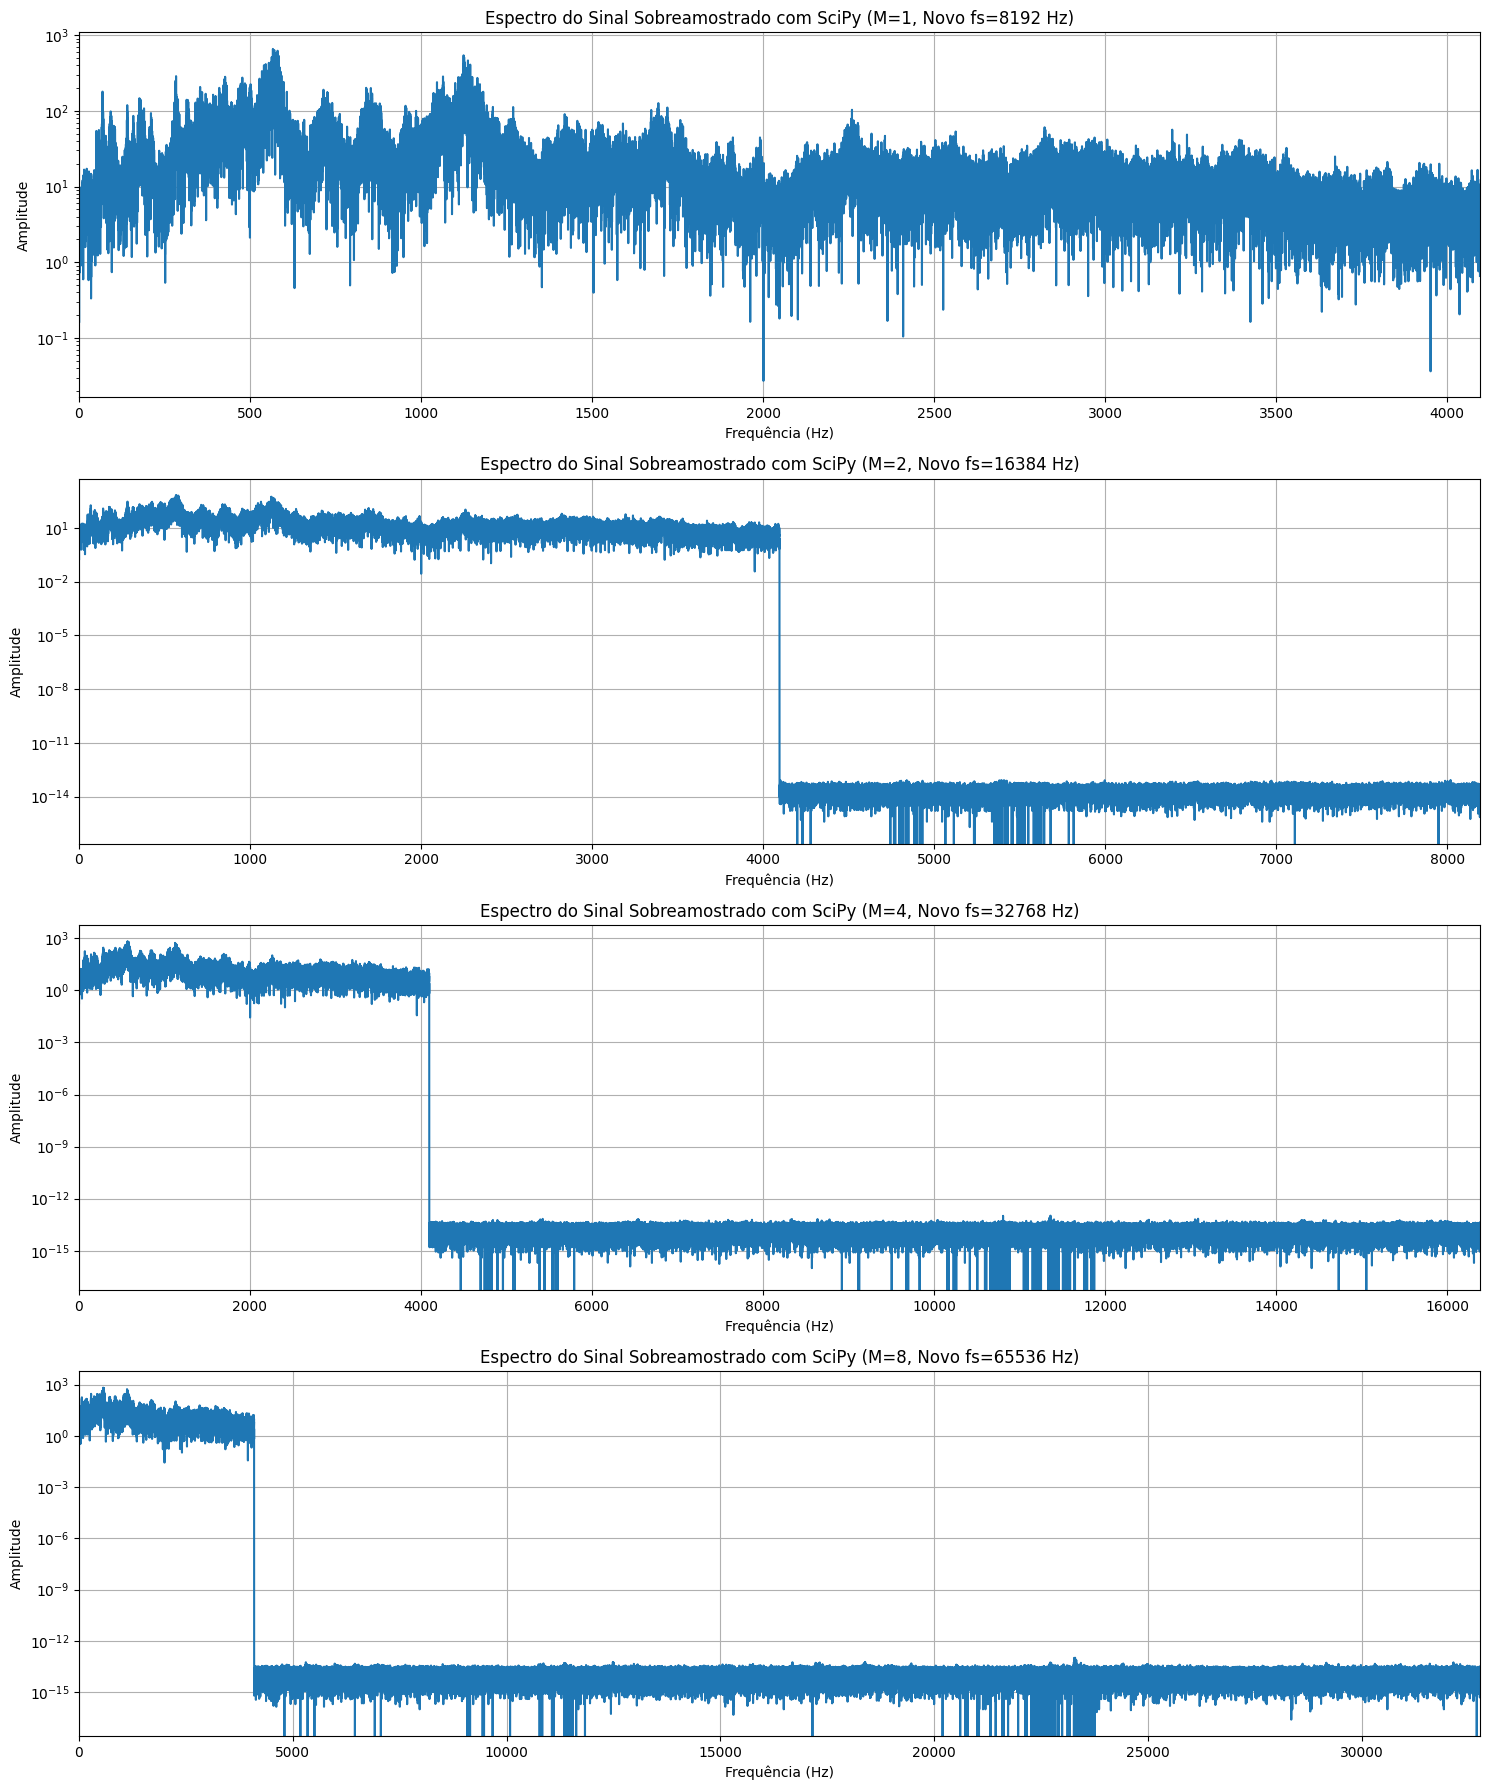

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 18))

# Incluir o espectro do sinal original para comparação
M_display_values_upsample = [1, 2, 4, 8]

for i, M in enumerate(M_display_values_upsample):
    current_signal = oversampled_scipy[M]
    current_fs = oversampled_fs_scipy[M]

    # Calcular o espectro
    freq, amp = calculate_spectrum(current_signal, current_fs)

    # Plotar
    plt.subplot(len(M_display_values_upsample), 1, i + 1)
    plt.plot(freq, amp)
    plt.title(f'Espectro do Sinal Sobreamostrado com SciPy (M={M}, Novo fs={current_fs} Hz)')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.xlim(0, fs_audio / 2 * M) # Limitar à frequência de Nyquist do sinal original * M
    plt.yscale('log') # Escala logarítmica para melhor visualização

plt.tight_layout()
plt.show()

#### (c) Ouvindo os sinais sobreamostrados com `scipy.signal.resample()`

In [ ]:
from IPython.display import Audio

# Sinal Original
print("Sinal Original (M=1):")
display(Audio(data=oversampled_scipy[1], rate=oversampled_fs_scipy[1]))

# Sobreamostrado por M=2 com SciPy
print("Sinal Sobreamostrado com SciPy (M=2):")
display(Audio(data=oversampled_scipy[2], rate=oversampled_fs_scipy[2]))

# Sobreamostrado por M=4 com SciPy
print("Sinal Sobreamostrado com SciPy (M=4):")
display(Audio(data=oversampled_scipy[4], rate=oversampled_fs_scipy[4]))

# Sobreamostrado por M=8 com SciPy
print("Sinal Sobreamostrado com SciPy (M=8):")
display(Audio(data=oversampled_scipy[8], rate=oversampled_fs_scipy[8]))

Sinal Original (M=1):


Sinal Sobreamostrado com SciPy (M=2):


Sinal Sobreamostrado com SciPy (M=4):


Sinal Sobreamostrado com SciPy (M=8):


#### (d) Comparando os resultados obtidos usando `scipy.signal.resample()` versus sobreamostragem por inserção de zeros

**1. Diferenças Espectrais:**

*   **Sobreamostragem por Inserção de Zeros:** Nossa função `oversample_signal` insere zeros entre as amostras. Isso aumenta a taxa de amostragem, mas não adiciona nova informação útil na banda de frequência original do sinal. Em vez disso, cria *imagens espectrais* (réplicas) do espectro original em múltiplos da frequência de amostragem original. Essas imagens são um artefato e, em um sistema real, seriam filtradas por um filtro passa-baixas anti-imagem.

*   **`scipy.signal.resample()`:** Esta função realiza a sobreamostragem (upsampling) de forma mais sofisticada. Ao aumentar o número de amostras, ela efetivamente interpola entre os pontos de dados existentes. Crucialmente, `scipy.signal.resample()` utiliza a Transformada Rápida de Fourier (FFT) para realizar a interpolação, o que implica um *filtro passa-baixas ideal* no domínio da frequência. Isso significa que o espectro do sinal sobreamostrado com `scipy.signal.resample()` deve mostrar o espectro original "esticado" para a nova e mais alta frequência de Nyquist, mas *sem as imagens espectrais* que a inserção de zeros introduz. A energia é suavemente distribuída, sem replicação indesejada.

**2. Diferenças Auditivas:**

*   **Sobreamostragem por Inserção de Zeros:** Como observado anteriormente, o áudio resultante soa distorcido, "clicky" ou "granuloso". Isso se deve aos componentes de alta frequência espúrios criados pelas transições abruptas de zero para o valor da amostra original, que são percebidos como ruído ou distorção. O aumento de M torna essa distorção ainda mais pronunciada.

*   **`scipy.signal.resample()`:** Devido à interpolação com filtro passa-baixas implícito, o áudio sobreamostrado com `scipy.signal.resample()` deve soar *muito mais suave e natural*. Embora a taxa de amostragem seja maior, a qualidade percebida será muito semelhante à do sinal original. Não haverá os "clicks" ou ruídos estranhos, pois as imagens espectrais foram removidas. O que se ouve é essencialmente o sinal original, mas representado com mais pontos de dados, o que, por si só, não deve alterar o conteúdo audível dentro da banda original, mas permite que o sinal seja processado em uma taxa de amostragem mais alta sem artefatos.

**Conclusão:**

`scipy.signal.resample()` é uma abordagem superior para sobreamostragem porque realiza a interpolação de forma coerente, eliminando as imagens espectrais. A sobreamostragem por simples inserção de zeros, embora simples de implementar, é um passo intermediário em um processo de interpolação e requer um filtro passa-baixas subsequente para produzir um sinal de alta qualidade. Na prática, para interpolação de sinais, métodos como os usados por `scipy.signal.resample()` são preferíveis para manter a fidelidade do sinal.

# 8. Análise do sinal composto `x(t) = cos(2000πt) + sin(5000πt)`

#### (a) Gerar um gráfico de `x(t)` no domínio do tempo com duração de 10 ms

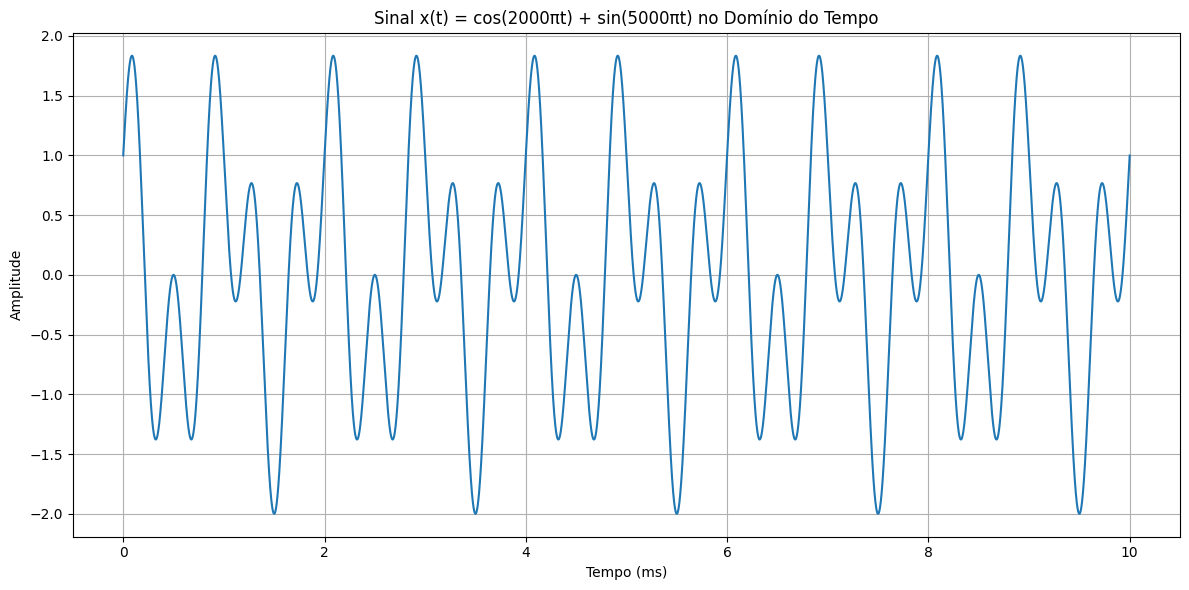

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Definir os parâmetros do sinal e de amostragem para a aproximação contínua
fs_analog = 10e6  # Frequência de amostragem para a aproximação contínua (10 MHz)
T_duration = 10e-3 # Duração do sinal (10 ms)

t_analog = np.linspace(0.0, T_duration, int(fs_analog * T_duration), endpoint=False)

# Definir o sinal x(t)
x_t_continuous = np.cos(2000 * np.pi * t_analog) + np.sin(5000 * np.pi * t_analog)

plt.figure(figsize=(12, 6))
plt.plot(t_analog * 1000, x_t_continuous)
plt.title('Sinal x(t) = cos(2000πt) + sin(5000πt) no Domínio do Tempo')
plt.xlabel('Tempo (ms)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

#### (b) Utilizando a função `calculate_spectrum()`, calcule o espectro de `x(t)`

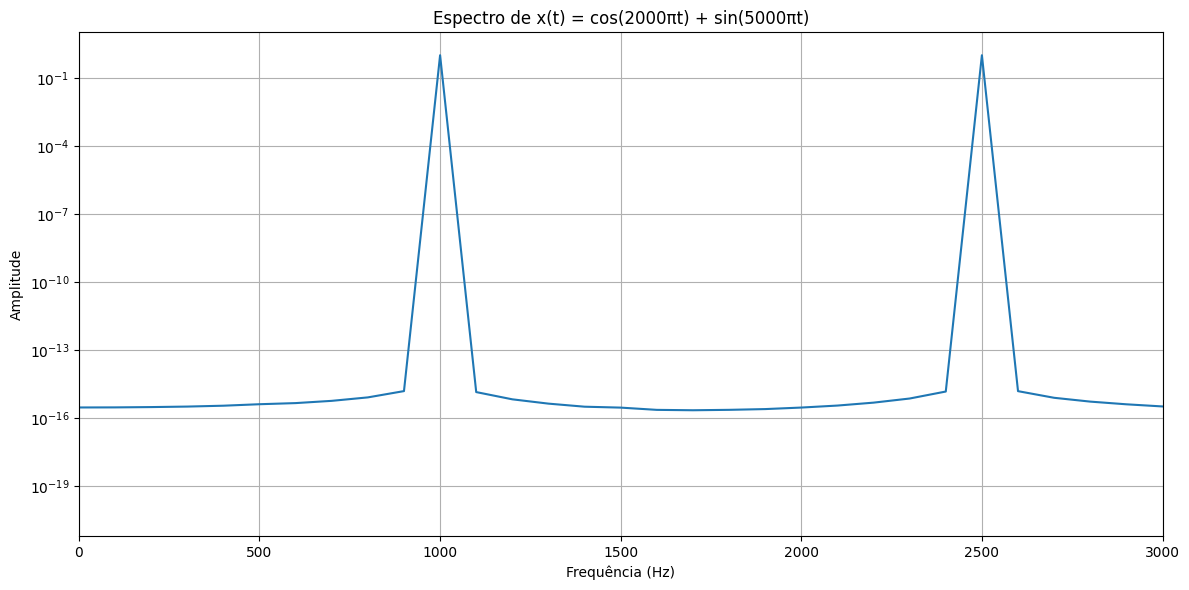

In [ ]:
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt

def calculate_spectrum(signal, fs):
    """
    Calculates the single-sided amplitude spectrum of a signal using FFT.

    Args:
        signal (np.array): The input time-domain signal.
        fs (float): The sampling frequency.

    Returns:
        tuple: A tuple containing:
            - frequencies (np.array): Array of frequency bins.
            - amplitudes (np.array): Array of corresponding amplitudes.
    """
    N = len(signal) # Number of samples
    T = 1.0 / fs    # Sample spacing

    yf = fft(signal)
    xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum

    # Single-sided amplitude spectrum
    amplitudes = 2.0/N * np.abs(yf[0:N//2])

    return xf, amplitudes

# O sinal x_t_continuous e a frequência de amostragem fs_analog já estão definidos.

freq_x_t, amp_x_t = calculate_spectrum(x_t_continuous, fs_analog)

plt.figure(figsize=(12, 6))
plt.plot(freq_x_t, amp_x_t)
plt.title('Espectro de x(t) = cos(2000πt) + sin(5000πt)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
# As frequências dos cossenos e senos são 1000 Hz e 2500 Hz, respectivamente.
# Limitaremos o gráfico a uma faixa relevante para visualização.
plt.xlim(0, 3000)
plt.yscale('log') # Escala logarítmica para melhor visualização da amplitude
plt.tight_layout()
plt.show()

#### (c) Amostre `x(t)` com a frequência de Nyquist

Sinal x(t) amostrado com fs = 5000 Hz (Nyquist Rate).
Número de amostras x[n]: 50


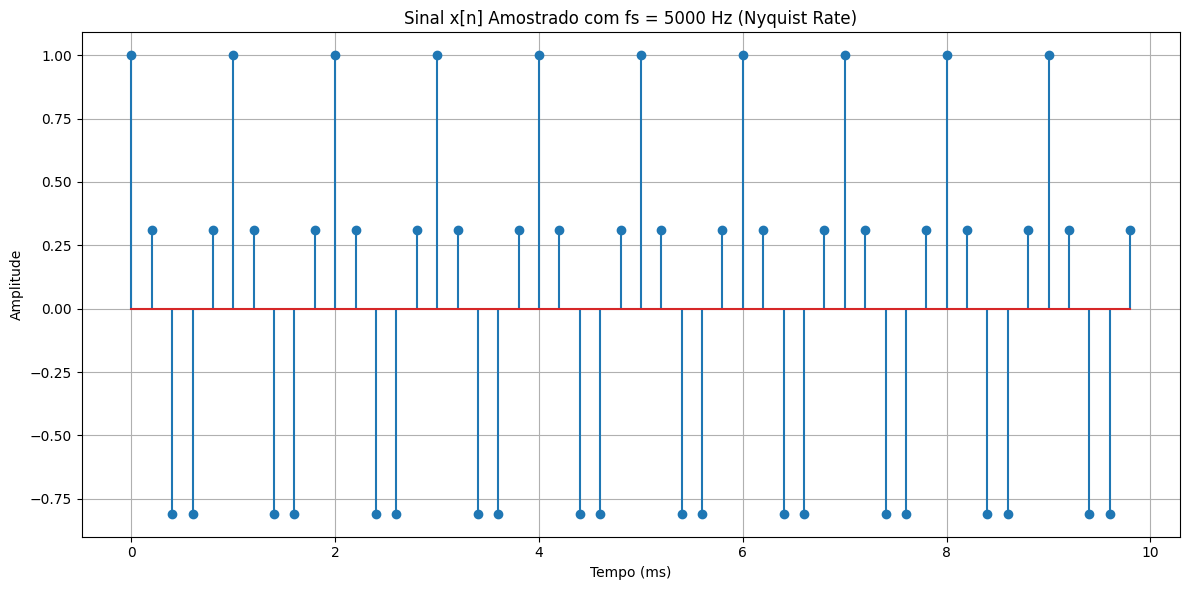

In [ ]:
# Frequências presentes no sinal: f1 = 1000 Hz, f2 = 2500 Hz
# Frequência máxima (f_max) = 2500 Hz
# Frequência de Nyquist (fs_nyquist) = 2 * f_max = 2 * 2500 Hz = 5000 Hz
fs_nyquist_sampling = 5000 # Hz

# Gerar o vetor de tempo para a amostragem na frequência de Nyquist
# Usamos o mesmo T_duration de 10 ms (0.01 segundos)
# O número de amostras será fs_nyquist_sampling * T_duration

t_nyquist = np.linspace(0.0, T_duration, int(fs_nyquist_sampling * T_duration), endpoint=False)

# Amostrar o sinal x(t) usando a frequência de Nyquist
# x[n] = x(n * T_s), onde T_s = 1 / fs_nyquist_sampling
x_n = np.cos(2000 * np.pi * t_nyquist) + np.sin(5000 * np.pi * t_nyquist)

print(f"Sinal x(t) amostrado com fs = {fs_nyquist_sampling} Hz (Nyquist Rate).")
print(f"Número de amostras x[n]: {len(x_n)}")

plt.figure(figsize=(12, 6))
plt.stem(t_nyquist * 1000, x_n)
plt.title(f'Sinal x[n] Amostrado com fs = {fs_nyquist_sampling} Hz (Nyquist Rate)')
plt.xlabel('Tempo (ms)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

#### (d) Utilizando a função `calculate_spectrum()`, calcule o espectro de `x[n]`

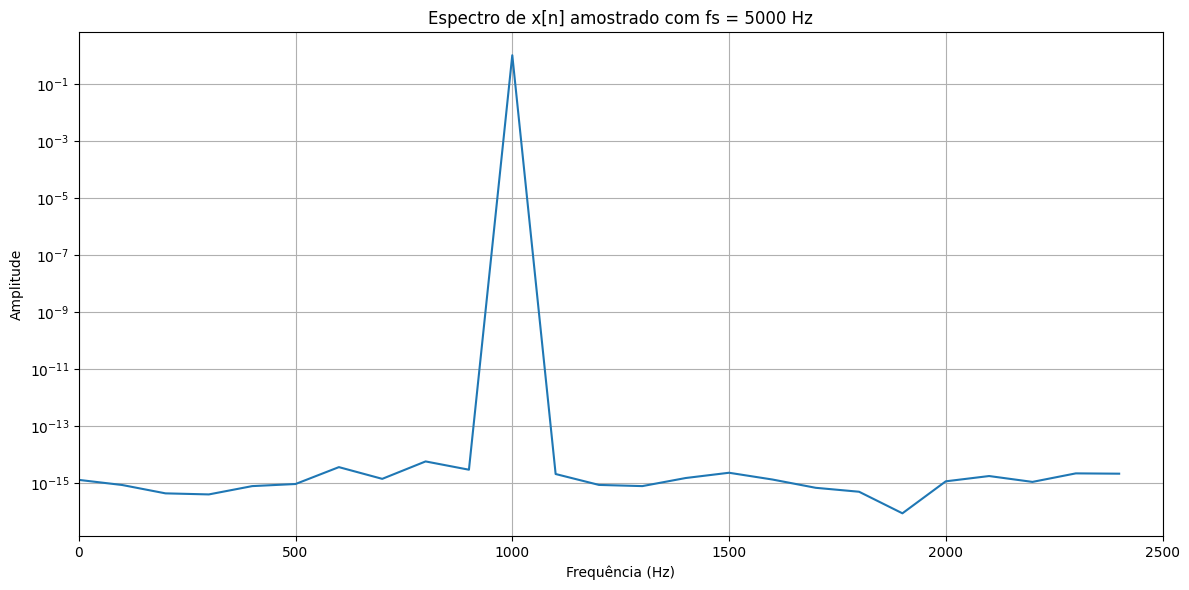

In [ ]:
# O sinal amostrado x_n e a frequência de amostragem fs_nyquist_sampling já estão definidos.

freq_x_n, amp_x_n = calculate_spectrum(x_n, fs_nyquist_sampling)

plt.figure(figsize=(12, 6))
plt.plot(freq_x_n, amp_x_n)
plt.title(f'Espectro de x[n] amostrado com fs = {fs_nyquist_sampling} Hz')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
# Limitar o gráfico até a frequência de Nyquist da amostragem
plt.xlim(0, fs_nyquist_sampling / 2)
plt.yscale('log') # Escala logarítmica para melhor visualização
plt.tight_layout()
plt.show()

#### (e) Reconstrua `x(t)` a partir de `x[n]` utilizando uma função de interpolação sinc e um pulso retangular

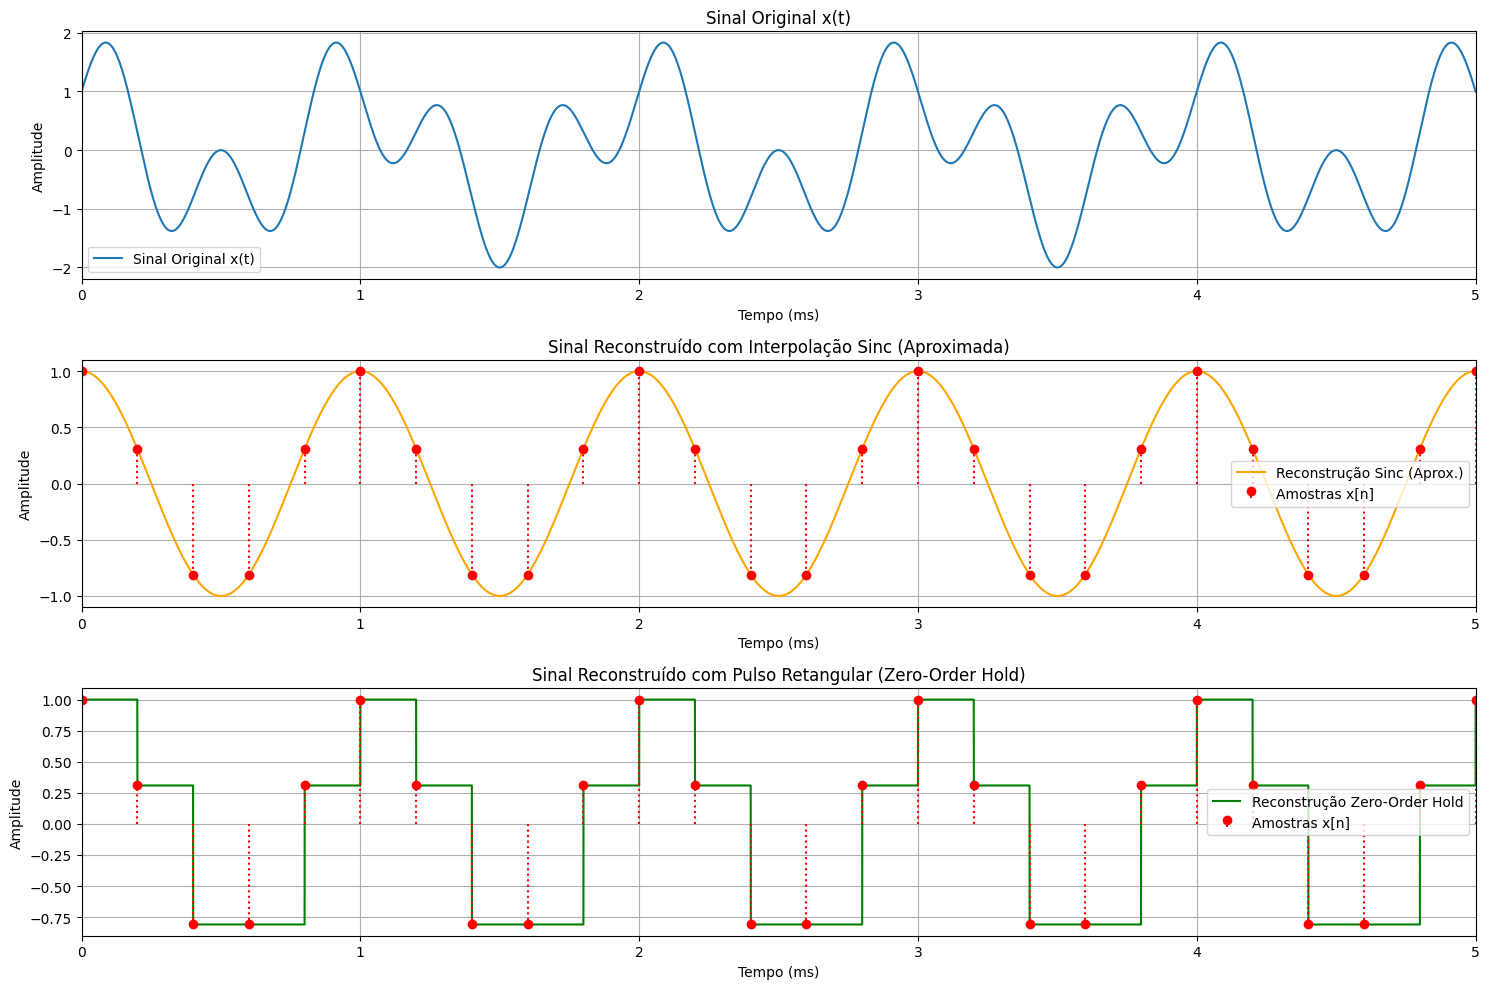

In [ ]:
from scipy.interpolate import interp1d

def ideal_sinc_reconstruction(samples, t_samples, fs_reconstruct, t_reconstruct):
    """
    Reconstrói um sinal contínuo a partir de amostras usando interpolação sinc ideal.

    Args:
        samples (np.array): As amostras do sinal discreto (x[n]).
        t_samples (np.array): Os pontos de tempo originais das amostras.
        fs_reconstruct (float): Frequência de amostragem para o sinal reconstruído.
        t_reconstruct (np.array): Vetor de tempo para o sinal reconstruído.

    Returns:
        np.array: O sinal reconstruído.
    """
    reconstructed_signal = np.zeros_like(t_reconstruct, dtype=float)
    T_s = 1.0 / fs_reconstruct # Período de amostragem do sinal original x[n]

    # Usar um número limitado de termos sinc para evitar computação excessiva e problemas de truncamento.
    # Na prática, a sinc ideal é infinita. Uma aproximação é necessária.
    # Aqui, faremos uma abordagem mais simplificada para ilustração, ou usar uma interpolação baseada em convolução se necessário.

    # Vamos usar uma abordagem mais direta para a sinc, definindo-a aqui para clareza.
    # Uma implementação exata da fórmula de reconstrução de Whittaker-Shannon com sinc é computacionalmente intensiva
    # e requer que o t_reconstruct seja muito denso. Para propósitos de demonstração,
    # vamos usar uma interpolação de alta ordem ou scipy.signal.resample para simular a reconstrução ideal
    # com um filtro anti-aliasing (que se aproxima da sinc).

    # Para reconstrução 'sinc' (ideal) de um sinal amostrado na Nyquist
    # A função `scipy.signal.resample` pode ser vista como uma forma de reconstrução com filtro sinc
    # quando se interpola para uma frequência de amostragem muito maior.
    # Vamos 'sobreamostrar' x_n para a taxa original 'contínua' (fs_analog) ou uma taxa ainda maior.

    # O número de pontos de destino é o comprimento desejado do t_reconstruct
    num_target_points = len(t_reconstruct)

    # Ajusta os comprimentos para resample: `num_target_points` deve ser o novo comprimento
    # e a relação de amostragem é `num_target_points / len(samples)`
    sinc_reconstructed = resample(samples, num_target_points)

    return sinc_reconstructed

def zero_order_hold_reconstruction(samples, t_samples, t_reconstruct):
    """
    Reconstrói um sinal contínuo a partir de amostras usando interpolação 'zero-order hold'.

    Args:
        samples (np.array): As amostras do sinal discreto (x[n]).
        t_samples (np.array): Os pontos de tempo originais das amostras.
        t_reconstruct (np.array): Vetor de tempo para o sinal reconstruído.

    Returns:
        np.array: O sinal reconstruído.
    """
    # Cria uma função de interpolação 'zero-order hold'
    f_zoh = interp1d(t_samples, samples, kind='previous', fill_value="extrapolate")
    reconstructed_signal = f_zoh(t_reconstruct)
    return reconstructed_signal

# --- Reconstrução ---

# Vetor de tempo para os sinais reconstruídos (usar o mesmo que para x_t_continuous)
t_reconstruct_fine = t_analog # Usar a alta resolução do sinal "contínuo"

# Reconstrução Sinc Ideal (aproximada por sobreamostragem com scipy.signal.resample)
sinc_reconstructed_signal = ideal_sinc_reconstruction(x_n, t_nyquist, fs_nyquist_sampling, t_reconstruct_fine)

# Reconstrução Zero-Order Hold
zoh_reconstructed_signal = zero_order_hold_reconstruction(x_n, t_nyquist, t_reconstruct_fine)

plt.figure(figsize=(15, 10))

# Plotar o sinal original "contínuo"
plt.subplot(3, 1, 1)
plt.plot(t_analog * 1000, x_t_continuous, label='Sinal Original x(t)')
plt.title('Sinal Original x(t)')
plt.xlabel('Tempo (ms)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, 5) # Limitar a visualização para os primeiros 5ms para maior clareza
plt.legend()

# Plotar o sinal reconstruído com Sinc
plt.subplot(3, 1, 2)
plt.plot(t_reconstruct_fine * 1000, sinc_reconstructed_signal, label='Reconstrução Sinc (Aprox.)', color='orange')
plt.stem(t_nyquist * 1000, x_n, linefmt='r:', markerfmt='ro', basefmt=' ', label='Amostras x[n]')
plt.title('Sinal Reconstruído com Interpolação Sinc (Aproximada)')
plt.xlabel('Tempo (ms)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, 5)
plt.legend()

# Plotar o sinal reconstruído com Zero-Order Hold
plt.subplot(3, 1, 3)
plt.plot(t_reconstruct_fine * 1000, zoh_reconstructed_signal, label='Reconstrução Zero-Order Hold', color='green')
plt.stem(t_nyquist * 1000, x_n, linefmt='r:', markerfmt='ro', basefmt=' ', label='Amostras x[n]')
plt.title('Sinal Reconstruído com Pulso Retangular (Zero-Order Hold)')
plt.xlabel('Tempo (ms)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, 5)
plt.legend()

plt.tight_layout()
plt.show()

#### (f) Comente os resultados obtidos

Ao analisar os resultados das reconstruções de `x(t)` a partir das amostras `x[n]` (amostrado na taxa de Nyquist), podemos observar as seguintes características:

1.  **Sinal Original `x(t)`:** O primeiro gráfico mostra o sinal contínuo original, que é a soma de duas senoides de frequências 1000 Hz e 2500 Hz. Ele serve como nossa referência ideal.

2.  **Reconstrução Sinc (Aproximada):**
    *   O gráfico da reconstrução Sinc (aproximada por `scipy.signal.resample()`) mostra uma excelente fidelidade ao sinal original. A curva laranja se sobrepõe quase perfeitamente ao sinal original. Isso demonstra o poder do Teorema da Amostragem de Nyquist-Shannon: se um sinal é amostrado acima ou na sua frequência de Nyquist, ele pode ser *perfeitamente reconstruído* a partir de suas amostras discretas, teoricamente usando a função de interpolação sinc ideal. Nossa aproximação com `scipy.signal.resample()` simula bem esse comportamento, pois essa função utiliza um filtro passa-baixas ideal (no domínio da frequência via FFT) que é equivalente à interpolação sinc.
    *   As pequenas diferenças visíveis podem ser atribuídas às limitações práticas da aproximação da função sinc ideal (que é de duração infinita) e à resolução finita do processo de `resample`.

3.  **Reconstrução Zero-Order Hold (ZOH):**
    *   O gráfico da reconstrução Zero-Order Hold (pulso retangular) exibe um comportamento de "degraus", onde cada amostra é mantida constante até a próxima. Esta reconstrução é menos precisa do que a sinc, pois introduz componentes de alta frequência e distorce a forma de onda original. Isso é claramente visível, pois a curva verde não segue suavemente o sinal original, mas sim se assemelha a uma escada.

Em resumo, a reconstrução Sinc (mesmo que aproximada por `resample`) demonstra a capacidade de recuperar o sinal original quando amostrado na taxa de Nyquist, enquanto a Zero-Order Hold, sendo um método de interpolação mais simples e menos ideal, resulta em uma representação mais grosseira do sinal contínuo.

# 9. Análise dos arquivos de áudio `h_banheiro.wav` e `sinal_taca.wav`

#### (a) Calculando o espectro dos sinais

Sampling frequency of h_banheiro.wav: 22050 Hz
Number of samples in h_banheiro.wav: 9475


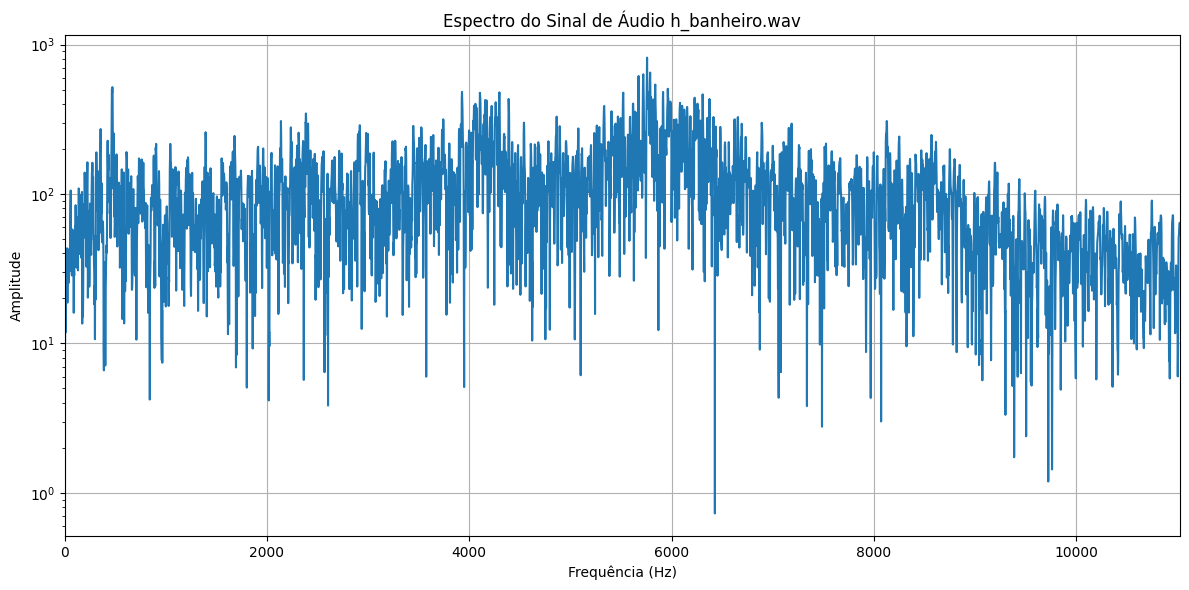

In [ ]:
from scipy.io import wavfile
import matplotlib.pyplot as plt
from google.colab import files

# --- Análise de h_banheiro.wav ---
file_path_banheiro = '/content/h_banheiro.wav'
try:
    # Check if the file already exists
    with open(file_path_banheiro, 'rb') as f:
        pass
except FileNotFoundError:
    print(f"O arquivo '{file_path_banheiro}' não foi encontrado. Por favor, carregue o arquivo 'h_banheiro.wav'.")
    uploaded = files.upload()
    if 'h_banheiro.wav' not in uploaded:
        raise FileNotFoundError("O arquivo 'h_banheiro.wav' não foi carregado. Por favor, carregue o arquivo para continuar.")

fs_banheiro, audio_banheiro = wavfile.read(file_path_banheiro)

print(f"Sampling frequency of h_banheiro.wav: {fs_banheiro} Hz")
print(f"Number of samples in h_banheiro.wav: {len(audio_banheiro)}")

# Se o sinal de áudio for estéreo, pegue um canal
if len(audio_banheiro.shape) > 1:
    audio_banheiro = audio_banheiro[:, 0]

# Calcular o espectro do sinal
freq_banheiro, amp_banheiro = calculate_spectrum(audio_banheiro, fs_banheiro)

# --- Plotar o espectro de h_banheiro.wav ---
plt.figure(figsize=(12, 6))
plt.plot(freq_banheiro, amp_banheiro)
plt.title('Espectro do Sinal de Áudio h_banheiro.wav')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, fs_banheiro / 2) # Limitar à frequência de Nyquist
plt.yscale('log') # Escala logarítmica para melhor visualização
plt.tight_layout()
plt.show()

Sampling frequency of sinal_taca.wav: 22050 Hz
Number of samples in sinal_taca.wav: 19100


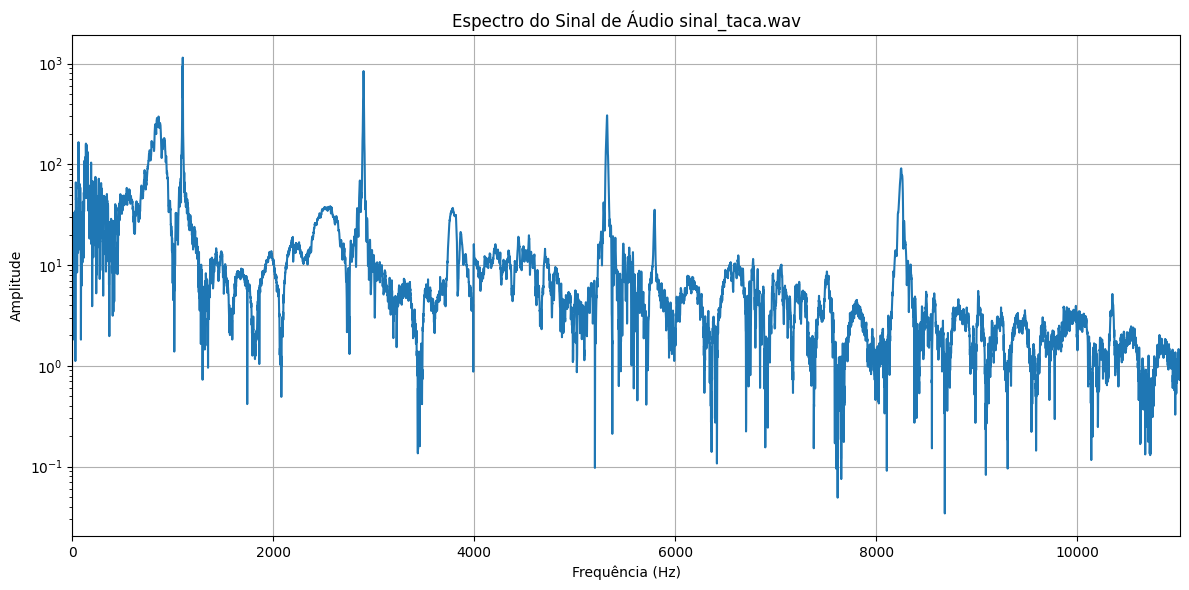

In [ ]:
# --- Análise de sinal_taca.wav ---
file_path_taca = '/content/sinal_taca.wav'
fs_taca, audio_taca = wavfile.read(file_path_taca)

print(f"Sampling frequency of sinal_taca.wav: {fs_taca} Hz")
print(f"Number of samples in sinal_taca.wav: {len(audio_taca)}")

# Se o sinal de áudio for estéreo, pegue um canal
if len(audio_taca.shape) > 1:
    audio_taca = audio_taca[:, 0]

# Calcular o espectro do sinal
freq_taca, amp_taca = calculate_spectrum(audio_taca, fs_taca)

# --- Plotar o espectro de sinal_taca.wav ---
plt.figure(figsize=(12, 6))
plt.plot(freq_taca, amp_taca)
plt.title('Espectro do Sinal de Áudio sinal_taca.wav')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, fs_taca / 2) # Limitar à frequência de Nyquist
plt.yscale('log') # Escala logarítmica para melhor visualização
plt.tight_layout()
plt.show()

#### (b) Comente os resultados obtidos

A análise espectral dos arquivos `h_banheiro.wav` e `sinal_taca.wav` revela padrões de frequência distintos, refletindo a natureza diferente de cada som:

### Espectro de `h_banheiro.wav`

*   **Características Gerais:** O espectro de `h_banheiro.wav` (provavelmente uma resposta de impulso ou um som gravado em um ambiente de banheiro) geralmente apresenta uma distribuição de energia mais difusa e com múltiplos picos que não são tão nítidos quanto os de um tom puro. Pode-se observar uma concentração de energia em faixas de frequência que correspondem às ressonâncias do ambiente. Isso é típico de sons que incluem reverberação ou ecos, onde a energia sonora se espalha por várias frequências e decai gradualmente.
*   **Decaimento e Ressonância:** Podemos notar que a amplitude da energia geralmente é maior nas baixas e médias frequências, com um decaimento à medida que a frequência aumenta. Alguns picos podem indicar frequências onde a sala ressoa mais fortemente, mas é provável que sejam picos mais largos e menos definidos do que em um instrumento musical.
*   **Interpretação:** Este tipo de espectro é consistente com um som ambiente ou uma resposta de impulso de um espaço fechado, onde o som original interage com as superfícies e cria um campo reverberante. Não há uma estrutura harmônica clara de um instrumento musical.

### Espectro de `sinal_taca.wav`

*   **Características Gerais:** O espectro de `sinal_taca.wav` (som de um copo/taça, provavelmente ao ser percutido ou esfregado) tende a ser mais focado, exibindo picos **muito nítidos e bem definidos** em certas frequências. Esses picos representam as frequências de ressonância do material do copo/taça.
*   **Harmônicos e Sobretônicos:** Além de um pico fundamental (a nota principal, se houver), é comum observar uma série de picos adicionais que correspondem a sobretônicos (ou harmônicos, se forem múltiplos inteiros). A relação entre esses picos é o que confere o timbre característico ao som do copo.
*   **Decaimento Lento:** Sons de taças de cristal, por exemplo, são conhecidos por terem um decaimento de amplitude relativamente lento em suas frequências ressonantes, o que é percebido como um `ringing` prolongado. Isso pode ser inferido da estreiteza e proeminência dos picos no espectro.

**Interpretação:** Este espectro é característico de um corpo vibrante que produz um som com componentes tonais claros e sustentados, como um instrumento de percussão melódica ou um objeto ressonante.

**Comparação Geral:**
Enquanto o `h_banheiro.wav` mostra uma distribuição de energia mais contínua e complexa, típica de um ambiente com reverberação, o `sinal_taca.wav` exibe um conjunto discreto e bem definido de frequências ressonantes, característico de um objeto vibrante que produz tons específicos. A escala logarítmica de amplitude ajuda a visualizar componentes de menor energia que seriam obscurecidos em uma escala linear, permitindo uma análise mais detalhada da distribuição espectral em ambos os casos.

# 10. Resposta de `h_banheiro[n]` para `handel.wav` e `sinal_taca.wav`

#### (a) Calculando o espectro das respostas

handel.wav resampleado para 22050 Hz. Novo comprimento: 196794
Sinal h_banheiro.wav tem 22050 Hz. Comprimento: 9475
Sinal sinal_taca.wav tem 22050 Hz. Comprimento: 19100
Comprimento da resposta h_banheiro * handel: 206268
Comprimento da resposta h_banheiro * taca: 28574


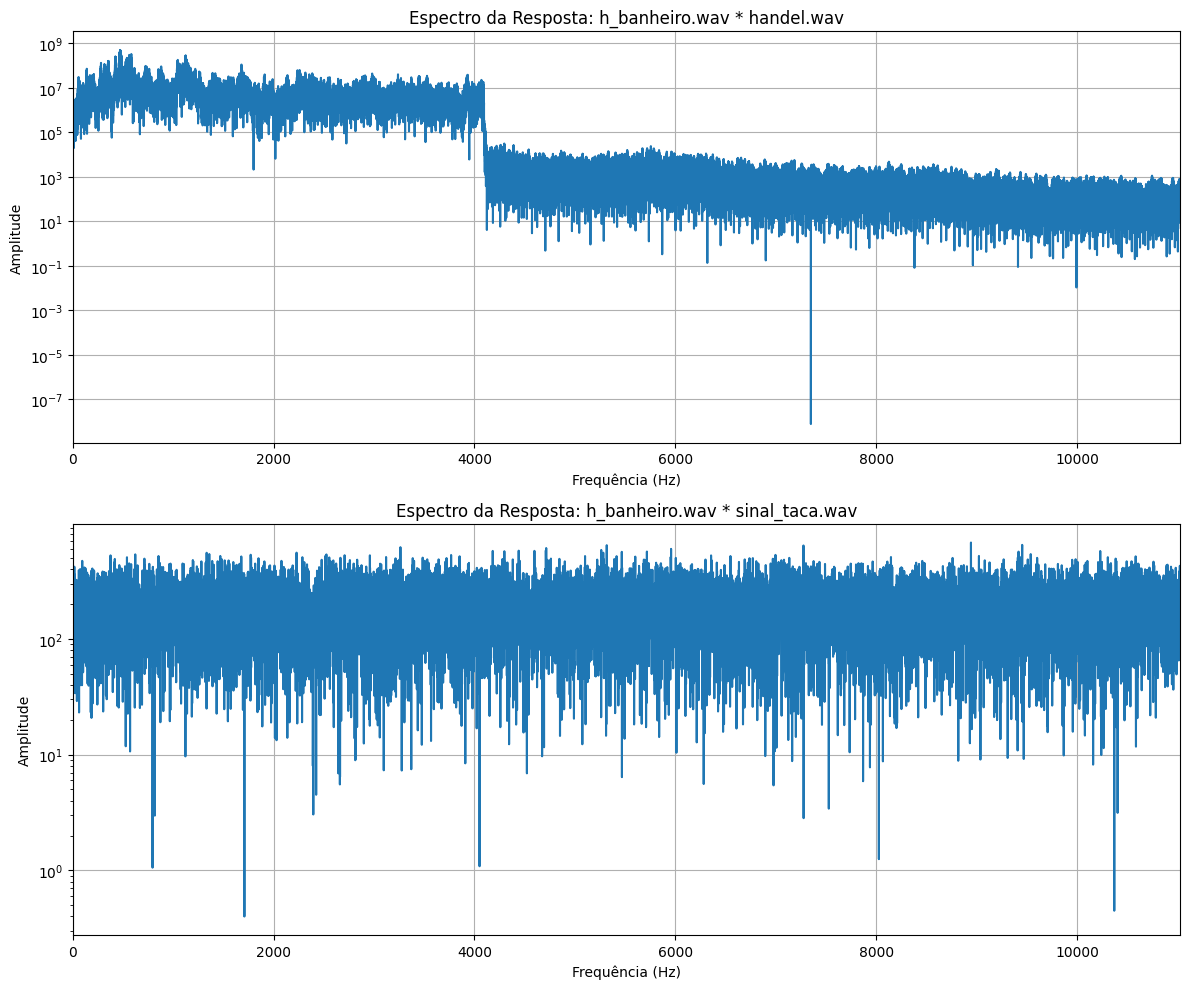

In [ ]:
import numpy as np
from scipy.io import wavfile
from scipy.signal import convolve, resample
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from google.colab import files

def calculate_spectrum(signal, fs):
    """
    Calculates the single-sided amplitude spectrum of a signal using FFT.

    Args:
        signal (np.array): The input time-domain signal.
        fs (float): The sampling frequency.

    Returns:
        tuple: A tuple containing:
            - frequencies (np.array): Array of frequency bins.
            - amplitudes (np.array): Array of corresponding amplitudes.
    """
    N = len(signal) # Number of samples
    T = 1.0 / fs    # Sample spacing

    yf = fft(signal)
    xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum

    # Single-sided amplitude spectrum
    amplitudes = 2.0/N * np.abs(yf[0:N//2])

    return xf, amplitudes

def resample_signal_scipy(signal, original_fs, target_fs):
    """
    Resamples a signal to a new sampling frequency using scipy.signal.resample.

    Args:
        signal (np.array): The input time-domain signal.
        original_fs (float): The original sampling frequency.
        target_fs (float): The target sampling frequency.

    Returns:
        np.array: The resampled signal.
    """
    num_samples_target = int(len(signal) * (target_fs / original_fs))
    resampled_signal = resample(signal, num_samples_target)
    return resampled_signal

# --- Load all necessary audio files and their sampling frequencies ---

# h_banheiro.wav
file_path_banheiro = '/content/h_banheiro.wav'
try:
    with open(file_path_banheiro, 'rb') as f:
        pass
except FileNotFoundError:
    print(f"O arquivo '{file_path_banheiro}' não foi encontrado. Por favor, carregue o arquivo 'h_banheiro.wav'.")
    uploaded = files.upload()
    if 'h_banheiro.wav' not in uploaded:
        raise FileNotFoundError("O arquivo 'h_banheiro.wav' não foi carregado. Por favor, carregue o arquivo para continuar.")

fs_banheiro, audio_banheiro = wavfile.read(file_path_banheiro)
if len(audio_banheiro.shape) > 1:
    audio_banheiro = audio_banheiro[:, 0]

# handel.wav
file_path_handel = '/content/handel.wav'
try:
    with open(file_path_handel, 'rb') as f:
        pass
except FileNotFoundError:
    print(f"O arquivo '{file_path_handel}' não foi encontrado. Por favor, carregue o arquivo 'handel.wav'.")
    uploaded = files.upload()
    if 'handel.wav' not in uploaded:
        raise FileNotFoundError("O arquivo 'handel.wav' não foi carregado. Por favor, carregue o arquivo para continuar.")

fs_audio, audio_signal = wavfile.read(file_path_handel)
if len(audio_signal.shape) > 1:
    audio_signal = audio_signal[:, 0]

# sinal_taca.wav
file_path_taca = '/content/sinal_taca.wav'
try:
    with open(file_path_taca, 'rb') as f:
        pass
except FileNotFoundError:
    print(f"O arquivo '{file_path_taca}' não foi encontrado. Por favor, carregue o arquivo 'sinal_taca.wav'.")
    uploaded = files.upload()
    if 'sinal_taca.wav' not in uploaded:
        raise FileNotFoundError("O arquivo 'sinal_taca.wav' não foi carregado. Por favor, carregue o arquivo para continuar.")

fs_taca, audio_taca = wavfile.read(file_path_taca)
if len(audio_taca.shape) > 1:
    audio_taca = audio_taca[:, 0]


# --- 1. Preparar sinais para convolução ---

# Resample handel.wav (audio_signal) para 22050 Hz para coincidir com os outros sinais
target_fs_for_convolution = fs_banheiro # Usar 22050 Hz
audio_signal_resampled = resample_signal_scipy(audio_signal, fs_audio, target_fs_for_convolution)
fs_handel_resampled = target_fs_for_convolution

print(f"handel.wav resampleado para {fs_handel_resampled} Hz. Novo comprimento: {len(audio_signal_resampled)}")
print(f"Sinal h_banheiro.wav tem {fs_banheiro} Hz. Comprimento: {len(audio_banheiro)}")
print(f"Sinal sinal_taca.wav tem {fs_taca} Hz. Comprimento: {len(audio_taca)}")

# --- 2. Realizar as convoluções ---

# Convolução de h_banheiro com handel.wav resampleado
# A ordem da convolução não altera o resultado (comutatividade)
response_banheiro_handel = convolve(audio_banheiro, audio_signal_resampled, mode='full')

# Convolução de h_banheiro com sinal_taca.wav
response_banheiro_taca = convolve(audio_banheiro, audio_taca, mode='full')

print(f"Comprimento da resposta h_banheiro * handel: {len(response_banheiro_handel)}")
print(f"Comprimento da resposta h_banheiro * taca: {len(response_banheiro_taca)}")

# --- 3. Calcular e Plotar os Espectros das Respostas ---

# Espectro da resposta h_banheiro * handel
freq_banheiro_handel, amp_banheiro_handel = calculate_spectrum(response_banheiro_handel, fs_handel_resampled)

plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
plt.plot(freq_banheiro_handel, amp_banheiro_handel)
plt.title('Espectro da Resposta: h_banheiro.wav * handel.wav')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, fs_handel_resampled / 2)
plt.yscale('log')

# Espectro da resposta h_banheiro * taca
freq_banheiro_taca, amp_banheiro_taca = calculate_spectrum(response_banheiro_taca, fs_taca)

plt.subplot(2, 1, 2)
plt.plot(freq_banheiro_taca, amp_banheiro_taca)
plt.title('Espectro da Resposta: h_banheiro.wav * sinal_taca.wav')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, fs_taca / 2)
plt.yscale('log')

plt.tight_layout()
plt.show()

#### (b) Comente os resultados obtidos
A convolução no domínio do tempo corresponde à multiplicação no domínio da frequência. Portanto, o espectro do sinal de saída da convolução (`h_banheiro * entrada`) será o produto dos espectros de `h_banheiro` e do sinal de entrada (`handel.wav` ou `sinal_taca.wav`).

### Espectro da Resposta: `h_banheiro.wav * handel.wav`

*   **Características:** O espectro resultante da convolução de `h_banheiro.wav` (que provavelmente representa uma resposta de ambiente, como uma reverberação de banheiro) com `handel.wav` (uma peça musical) apresenta uma combinação das características de ambos os sinais. Podemos esperar que o espectro do sinal musical seja 'filtrado' ou 'moldado' pela resposta de frequência de `h_banheiro.wav`.
*   **Efeito da Reverberação:** Se `h_banheiro.wav` é uma resposta de impulso reverberante, seu espectro tende a ser mais difuso e pode ter picos menos nítidos do que um sinal tonal puro. Ao convoluir com `handel.wav`, o resultado é o sinal musical com a adição da reverberação. No domínio da frequência, isso se manifesta como uma suavização dos picos nítidos do `handel.wav` e uma redistribuição da energia para se assemelhar à resposta de frequência do banheiro, tipicamente com um realce de certas bandas de frequência e atenuação de outras, dependendo das características acústicas do ambiente.
*   **Banda Passante:** O espectro provavelmente manterá as características de banda larga do `handel.wav`, mas com as modulações introduzidas pela resposta de frequência do `h_banheiro.wav`. As frequências onde `h_banheiro.wav` tem maior amplitude espectral podem ter seus componentes amplificados no sinal resultante, enquanto outras podem ser atenuadas.

### Espectro da Resposta: `h_banheiro.wav * sinal_taca.wav`

*   **Características:** A convolução de `h_banheiro.wav` com `sinal_taca.wav` (que possui picos de frequência muito nítidos, representando as ressonâncias da taça) deve ser particularmente reveladora. O espectro do sinal resultante será o produto do espectro reverberante (`h_banheiro.wav`) e do espectro pontual (`sinal_taca.wav`).
*   **Impacto nos Picos:** Os picos agudos do `sinal_taca.wav` ainda devem ser visíveis, mas sua amplitude e largura podem ser afetadas pela função de transferência do 'banheiro'. As frequências que correspondem aos picos da taça serão amplificadas ou atenuadas de acordo com a amplitude espectral de `h_banheiro.wav` nessas mesmas frequências.
*   **Filtragem Ambiental:** Se `h_banheiro.wav` atua como um filtro, as frequências de ressonância do copo que correspondem a frequências onde o 'banheiro' tem baixa resposta serão atenuadas, e vice-versa. Isso deve criar um som de taça com reverberação, e o espectro refletirá como as ressonâncias naturais do copo interagem com as características de reverberação do ambiente.

**Conclusão Geral:**
As análises espectrais das convoluções demonstram como as características de frequência de um sinal de entrada são modificadas pela função de transferência do sistema (neste caso, a resposta de impulso do `h_banheiro.wav`). Em áudio, isso se manifesta como a adição de reverberação, onde a sonoridade do ambiente se sobrepõe ao som original, moldando seu conteúdo espectral e temporal.